# Subperiod Analysis: Temporal Stability of FF6 Alphas

## Overview
This Jupyter Notebook analyzes the temporal stability of Fama-French six-factor (FF6) alphas for quality signals across three sub-periods: Early (1963-1979), Middle (1980-1999), and Recent (2000-2024). It computes annualized alphas, Newey-West t-statistics, and generates academic tables and visualizations.

## Key Features
- **Automated Signal Selection**: Loads regression results, selects signals with significant FF6 alphas, prioritizing "Cash Cushion".
- **Sub-Period Splitting**: Divides data into three market regimes for robustness checks.
- **Comprehensive Regressions**: FF6 models with Newey-West standard errors (12 lags) for alphas and betas.
- **Multiple Outputs**: LaTeX tables for focused signals, all signals, and complete regressions; bar charts and heatmaps for visualization.
- **Decline Testing**: Formal tests for temporal decline in anomaly returns.

## Methodology
1. Load portfolio returns and FF6 factors from local files.
2. Filter signals based on full-sample significance (|t| > 3.0).
3. Compute FF6 alphas and t-statistics for each sub-period.
4. Generate LaTeX tables: focused (Cash Cushion + ROIC Momentum), extended (top signals), and comprehensive (all betas).
5. Create visualizations: ultra-wide bar chart (21:9 ratio) and enriched heatmap with annotations.
6. Perform regression-based decline tests (Alpha ~ Year).

## Dependencies
- Libraries: pandas, numpy, statsmodels, matplotlib, seaborn, pathlib.
- Data: Portfolio Parquet files, FF5 CSV, regression results Parquet.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Update CONFIG for periods, signals, and paths.
2. Run cells to load data, compute regressions, and generate outputs.
3. Review LaTeX tables in results/latex/ and figures in results/figures/.
4. Adjust visualization parameters for custom layouts.

## Output Files
- **results/latex/results_4_cash_roic_subperiods.tex**: LaTeX table for Cash Cushion and ROIC Momentum alphas.
- **results/latex/Appendix_subperiods_all.tex**: LaTeX table for all signals across sub-periods.
- **results/latex/results_4_subperiods_cash_first_extended.tex**: Extended LaTeX table for top signals ordered by alpha.
- **results/latex/Appendix_ff6_subperiods_8signals.tex**: Comprehensive LaTeX table with all FF6 betas for 8 signals.
- **results/figures/03_2_subperiod_21x9_ultrawide.png**: Ultra-wide bar chart (21:9) showing temporal stability.
- **results/figures/Appendix_subperiod_heatmap.png**: Heatmap with alphas, t-stats, and significance stars.

This notebook provides rigorous tests for the persistence of quality anomalies over time, bridging empirical analysis and academic reporting.

In [2]:
# %%
# 📦 IMPORTS
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


In [3]:
# %%
# ⚙️ CONFIGURATION

CONFIG = {
    # Période globale
    'start_date': '1963-07-01',
    'end_date': '2024-06-30',
    
    # Signaux à analyser
    'signals_to_test': 'all',  # 'all' OU dict {'Signal Name': 'file_name'}
    
    # Exemple manuel (décommenter si besoin) :
    # 'signals_to_test': {
    #     'Cash Cushion': 'cash_cushion',
    #     'ROIC Momentum': 'roic_momentum'
    # },
    
    # Sous-périodes académiques (Régimes de marché)
    'subperiods': {
        'Early (1963-1979)': ('1963-07-01', '1979-12-31'),
        'Middle (1980-1999)': ('1980-01-01', '1999-12-31'),
        'Recent (2000-2024)': ('2000-01-01', '2024-06-30')
    },
    
    # Facteurs FF
    'use_ff6': True,  # True = FF6 (FF5+MOM), False = FF5
    'newey_west_lags': 12,
    
    # Seuils
    'min_obs_subperiod': 24,  # Minimum 24 mois (2 ans)
    
    # Output
    'output_dir': Path('results/latex'),
    'figures_dir': Path('results/figures')
}

# Créer dossiers output
CONFIG['output_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['figures_dir'].mkdir(parents=True, exist_ok=True)

print("="*80)
print("📋 CONFIGURATION SUBPERIOD ANALYSIS (FF6 ALPHAS)")
print("="*80)
print(f"\n• Période globale     : {CONFIG['start_date']} → {CONFIG['end_date']}")
print(f"• Modèle factoriel    : {'FF6 (FF5+MOM)' if CONFIG['use_ff6'] else 'FF5'}")
print(f"• Newey-West lags     : {CONFIG['newey_west_lags']}")
print(f"• Nombre subperiods   : {len(CONFIG['subperiods'])}")
print(f"• Min obs/subperiod   : {CONFIG['min_obs_subperiod']} mois")
print("\n" + "="*80)

📋 CONFIGURATION SUBPERIOD ANALYSIS (FF6 ALPHAS)

• Période globale     : 1963-07-01 → 2024-06-30
• Modèle factoriel    : FF6 (FF5+MOM)
• Newey-West lags     : 12
• Nombre subperiods   : 3
• Min obs/subperiod   : 24 mois



In [4]:
# Mapping manuel : snake_case → Nom académique propre
SIGNAL_NAME_MAP = {
    # Leverage & Solvency
    'debt_maturity': 'Debt Maturity',
    'leverage_efficiency': 'Leverage Efficiency',
    
    # Profitability
    'op_margin_persist': 'OP Margin Persist',
    'earnings_quality': 'Earnings Quality',
    'ebitda_margin': 'EBITDA Margin',
    
    # Asset Efficiency
    'intangible_power': 'Intangible Power',
    'inv_margin': 'Inventory Margin',
    'receivables_turnover': 'Receivables Turnover',
    'ppe_productivity': 'PPE Productivity',
    'asset_turnover_quality': 'Asset Turnover Quality',
    
    # Liquidity
    'cash_cushion': 'Cash Cushion',
    
    # Capital Intensity
    'low_capex_high_margin': 'Low Capex High Margin',
    'depreciation_efficiency': 'Depreciation Efficiency',
    
    # Quality
    'gp_persist': 'GP Persist',
    'asset_tangibility': 'Asset Tangibility',
    'earnings_smoothness': 'Earnings Smoothness',
    
    # Accruals
    'noa_change': 'NOA Change',
    
    # Growth & Dynamics
    'earnings_accel': 'Earnings Accel',
    'sales_accel': 'Sales Acceleration',
    'recv_vs_sales': 'Recv vs Sales Growth',
    'growth_exhaustion': 'Growth Exhaustion',
    
    # Operating Leverage
    'sga_gp_leverage': 'SGA GP Leverage',
    
    # Returns Quality
    'investment_quality': 'Investment Quality',
    'roic_momentum': 'ROIC Momentum',
    'margin_stability_new': 'Margin Stability'
}

def clean_signal_name(signal_name: str) -> str:
    """
    Convertit nom technique en nom académique propre.
    
    Priority:
        1. Utiliser mapping manuel (SIGNAL_NAME_MAP)
        2. Fallback: snake_case → Title Case automatique
    
    Examples:
        'cash_cushion' → 'Cash Cushion'
        'noa_change' → 'NOA Change'
        'op_margin_persist' → 'OP Margin Persist'
    """
    if signal_name in SIGNAL_NAME_MAP:
        return SIGNAL_NAME_MAP[signal_name]
    else:
        # Fallback: Title Case basique
        return signal_name.replace('_', ' ').title()

In [5]:
# %%
# 📂 CHARGEMENT FACTEURS FAMA-FRENCH

def get_ff_factors(start_date, end_date, use_ff6=True):
    """
    Charger facteurs Fama-French depuis fichiers locaux.
    
    Returns:
        DataFrame avec colonnes [MKT, SMB, HML, RMW, CMA, MOM (optionnel), RF]
    """
    
    print("📂 Chargement des facteurs Fama-French depuis fichiers locaux...")
    
    try:
        # Charger FF5 (qui contient déjà UMD = Momentum)
        ff5_path = Path('data/famaFactors/FF5.csv')
        
        if not ff5_path.exists():
            raise FileNotFoundError(f"Fichier FF5 introuvable : {ff5_path}")
        
        factors = pd.read_csv(ff5_path)
        
        # Colonnes détectées : ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'rf', 'umd', 'dateff']
        
        # Convertir date (format ISO8601 : YYYY-MM-DD)
        factors['dateff'] = pd.to_datetime(factors['dateff'])
        factors = factors.set_index('dateff')
        
        # Renommer colonnes selon convention standard
        factors = factors.rename(columns={
            'mktrf': 'MKT',
            'smb': 'SMB',
            'hml': 'HML',
            'rmw': 'RMW',
            'cma': 'CMA',
            'rf': 'RF',
            'umd': 'MOM'  # UMD = Up Minus Down (Momentum)
        })
        
        # Sélectionner colonnes selon config
        if use_ff6:
            factor_cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'RF']
        else:
            factor_cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
        
        factors = factors[factor_cols]
        
        # Convertir en décimales si en pourcentages
        # (Détecter automatiquement : si valeurs > 1, c'est en %)
        if factors['MKT'].abs().mean() > 1:
            print("   ℹ️  Conversion % → décimales")
            factors = factors / 100.0
        
        # Aligner sur fin de mois
        factors.index = factors.index + pd.offsets.MonthEnd(0)
        
        # Filtrer période demandée
        factors = factors[
            (factors.index >= start_date) & 
            (factors.index <= end_date)
        ]
        
        print(f"✅ Facteurs chargés : {list(factors.columns)}")
        print(f"📅 Période couverte : {factors.index.min()} → {factors.index.max()}")
        print(f"📊 {len(factors)} observations")
        
        return factors
        
    except Exception as e:
        print(f"❌ Erreur chargement FF data : {e}")
        print(f"\n💡 Vérifiez la structure des fichiers CSV :")
        print(f"   • {ff5_path}")
        import traceback
        traceback.print_exc()
        return None

# Charger facteurs
factors = get_ff_factors(CONFIG['start_date'], CONFIG['end_date'], 
                         use_ff6=CONFIG['use_ff6'])

if factors is not None:
    print("\n" + "="*80)
    print("📊 APERÇU DES FACTEURS")
    print("="*80)
    print(factors.head())
    print("\n" + factors.describe().to_string())
    print("="*80)

📂 Chargement des facteurs Fama-French depuis fichiers locaux...
✅ Facteurs chargés : ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'RF']
📅 Période couverte : 1963-07-31 00:00:00 → 2024-06-30 00:00:00
📊 732 observations

📊 APERÇU DES FACTEURS
               MKT     SMB     HML     RMW     CMA     MOM      RF
dateff                                                            
1963-07-31 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0101  0.0027
1963-08-31  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0100  0.0025
1963-09-30 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0012  0.0027
1963-10-31  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0313  0.0029
1963-11-30 -0.0086 -0.0085  0.0173 -0.0043  0.0227 -0.0078  0.0027

              MKT         SMB         HML         RMW         CMA         MOM          RF
count  732.000000  732.000000  732.000000  732.000000  732.000000  732.000000  732.000000
mean     0.005820    0.001896    0.002847    0.002853    0.002551    0.005996    0.003633
std      0.044860    

In [6]:
# ...existing code...
# %%
# 📂 CHARGEMENT DONNÉES PORTFOLIOS (MODE STRICT & CORRIGÉ)

print("\n" + "="*80)
print("🔄 CHARGEMENT PORTFOLIOS (CALCUL FORCÉ SELON MAPPING)")
print("="*80 + "\n")

# 1. MAPPING DE DIRECTION (Strictement conforme à vos formules)
SIGNAL_DIRECTION_MAP = {
    # 1. LEVERAGE & SOLVENCY
    'debt_maturity': 'P10-P1',
    'leverage_efficiency': 'P10-P1',

    # 2. PROFITABILITY
    'op_margin_persist': 'P10-P1',
    'earnings_quality': 'P10-P1',      # High = Good
    'ebitda_margin': 'P10-P1',

    # 3. ASSET EFFICIENCY
    'intangible_power': 'P10-P1',
    'inv_margin': 'P10-P1',            # High Turnover = Good
    'receivables_turnover': 'P10-P1',
    'ppe_productivity': 'P10-P1',
    'asset_turnover_quality': 'P10-P1',

    # 4. LIQUIDITY / CASH
    'cash_cushion': 'P10-P1',

    # 5. CAPITAL INTENSITY
    'low_capex_high_margin': 'P10-P1',
    'depreciation_efficiency': 'P10-P1',

    # 6. QUALITY
    'gp_persist': 'P10-P1',
    'asset_tangibility': 'P1-P10',     # Low Tangibility (Asset Light) = Good
    'earnings_smoothness': 'P10-P1',

    # 7. ACCRUALS
    'noa_change': 'P1-P10',            # High Accruals = Bad

    # 8. GROWTH & DYNAMICS
    'earnings_accel': 'P10-P1',
    'sales_accel': 'P10-P1',
    'recv_vs_sales': 'P10-P1',         # High = Cash collected = Good
    'growth_exhaustion': 'P1-P10',     # High Growth = Risk of reversal

    # 9. OPERATING LEVERAGE
    'sga_gp_leverage': 'P10-P1',       # High = Positive Leverage

    # 10. RETURNS QUALITY
    'investment_quality': 'P10-P1',
    'roic_momentum': 'P10-P1',         # On veut voir si High Momentum bat Low
    'margin_stability_new': 'P10-P1',
}

# Détecter fichiers
portfolio_files = list(Path('data/portfolios').glob('*_signal.parquet'))

# Filtrer selon CONFIG
if CONFIG['signals_to_test'] == 'all':
    signals_to_process = [f.stem.replace('_signal', '') for f in portfolio_files]
else:
    signals_to_process = list(CONFIG['signals_to_test'].values())

print(f"✅ {len(signals_to_process)} signaux identifiés pour traitement\n")

returns_dict = {}

for file_name in signals_to_process:
    file_path = Path(f'data/portfolios/{file_name}_signal.parquet')
    pretty_name = file_name.replace('_', ' ').title()
    
    if not file_path.exists():
        print(f"⚠️  Fichier manquant : {file_name}")
        continue
    
    # Charger
    df = pd.read_parquet(file_path)
    df['date'] = pd.to_datetime(df['date']) + pd.offsets.MonthEnd(0)
    df = df.set_index('date')
    
    # Filtrer période (Alignement FF)
    df = df[
        (df.index >= CONFIG['start_date']) & 
        (df.index <= CONFIG['end_date'])
    ]
    
    # 🚨 CORRECTIF : STANDARDISER LES NOMS DE COLONNES
    # Les nouveaux fichiers utilisent 'ret_low_vw' / 'ret_high_vw'
    if 'ret_low_vw' in df.columns and 'ret_high_vw' in df.columns:
        df = df.rename(columns={
            'ret_low_vw': 'ret_p1_vw', 
            'ret_high_vw': 'ret_p10_vw'
        })
    
    # Vérifier colonnes requises
    if 'ret_p10_vw' not in df.columns or 'ret_p1_vw' not in df.columns:
        print(f"❌ {pretty_name:30} : Colonnes P1/P10 manquantes (Colonnes dispos: {list(df.columns)})")
        continue

    # 🚨 CALCUL FORCÉ (Cœur de la correction)
    direction = SIGNAL_DIRECTION_MAP.get(file_name, 'P10-P1') # Par défaut P10-P1
    
    if direction == 'P10-P1':
        # High minus Low
        ret_series = df['ret_p10_vw'] - df['ret_p1_vw']
        dir_label = "H-L"
    else:
        # Low minus High (Short High, Long Low)
        ret_series = df['ret_p1_vw'] - df['ret_p10_vw']
        dir_label = "L-H"
    
    returns_dict[pretty_name] = ret_series
    
    # Stats rapides pour vérification
    avg_ann = ret_series.mean() * 12 * 100
    print(f"   • {pretty_name:30} : {dir_label} ({direction}) | Moy: {avg_ann:6.2f}% | {len(ret_series)} obs")

print(f"\n✅ {len(returns_dict)} portfolios chargés et recalculés")
print("="*80)
# ...existing code...


🔄 CHARGEMENT PORTFOLIOS (CALCUL FORCÉ SELON MAPPING)

✅ 25 signaux identifiés pour traitement

   • Investment Quality             : H-L (P10-P1) | Moy:   0.62% | 732 obs
   • Leverage Efficiency            : H-L (P10-P1) | Moy:  -2.49% | 732 obs
   • Depreciation Efficiency        : H-L (P10-P1) | Moy:   1.79% | 732 obs
   • Asset Tangibility              : L-H (P1-P10) | Moy:  -2.58% | 732 obs
   • Sales Accel                    : H-L (P10-P1) | Moy:  -3.44% | 732 obs
   • Roic Momentum                  : H-L (P10-P1) | Moy:  -3.98% | 732 obs
   • Growth Exhaustion              : L-H (P1-P10) | Moy:   2.64% | 732 obs
   • Earnings Quality               : H-L (P10-P1) | Moy:   0.71% | 732 obs
   • Margin Stability New           : H-L (P10-P1) | Moy:  -2.10% | 732 obs
   • Intangible Power               : H-L (P10-P1) | Moy:   0.59% | 732 obs
   • Noa Change                     : L-H (P1-P10) | Moy:   4.46% | 732 obs
   • Earnings Accel                 : H-L (P10-P1) | Moy:  -2.80% | 

In [7]:
# %%
# 🔬 CALCUL FF6 ALPHAS PAR SOUS-PÉRIODE

def compute_ff_alpha_subperiod(returns, factors, start_date, end_date, 
                                use_ff6=True, nw_lags=6):
    """
    Calculer FF alpha + t-stat Newey-West pour une sous-période.
    
    Returns:
        dict avec {alpha_ann, t_stat, n_obs, betas}
    """
    
    # Filtrer dates
    mask = (returns.index >= start_date) & (returns.index <= end_date)
    y = returns[mask]
    X = factors.loc[y.index]
    
    if len(y) < 24:
        return None
    
    # Sélectionner facteurs
    if use_ff6:
        factor_cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    else:
        factor_cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA']
    
    # Régression OLS avec HAC (Newey-West)
    X_with_const = sm.add_constant(X[factor_cols])
    model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    
    # Résultats
    alpha_monthly = model.params['const']
    alpha_ann = alpha_monthly * 12 * 100  # En %
    t_stat = model.tvalues['const']
    
    return {
        'alpha_ann': alpha_ann,
        't_stat': t_stat,
        'n_obs': len(y),
        'betas': {col: model.params[col] for col in factor_cols}
    }

# Lancer analyse
print("\n" + "="*80)
print("🔬 ANALYSE FF6 ALPHAS PAR SOUS-PÉRIODE")
print("="*80 + "\n")

results_store = []

for signal_name, ret_series in returns_dict.items():
    print(f"📊 {signal_name}")
    
    for period_name, (start, end) in CONFIG['subperiods'].items():
        result = compute_ff_alpha_subperiod(
            ret_series, factors, start, end,
            use_ff6=CONFIG['use_ff6'],
            nw_lags=CONFIG['newey_west_lags']
        )
        
        if result is None:
            print(f"   ⚠️  {period_name:25} : Données insuffisantes")
            continue
        
        results_store.append({
            'Signal': signal_name,
            'Period': period_name,
            'Alpha': result['alpha_ann'],
            't_stat': result['t_stat'],
            'Obs': result['n_obs']
        })
        
        print(f"   ✅ {period_name:25} : α={result['alpha_ann']:6.2f}% (t={result['t_stat']:5.2f}, n={result['n_obs']})")

df_results = pd.DataFrame(results_store)

print("\n" + "="*80)
print(f"✅ {len(df_results)} alphas calculés")


🔬 ANALYSE FF6 ALPHAS PAR SOUS-PÉRIODE

📊 Investment Quality
   ✅ Early (1963-1979)         : α=  1.51% (t= 0.43, n=198)
   ✅ Middle (1980-1999)        : α=  4.34% (t= 1.35, n=240)
   ✅ Recent (2000-2024)        : α= -1.18% (t=-0.45, n=294)
📊 Leverage Efficiency
   ✅ Early (1963-1979)         : α= -2.34% (t=-0.76, n=198)
   ✅ Middle (1980-1999)        : α=  6.79% (t= 2.19, n=240)
   ✅ Recent (2000-2024)        : α= -4.52% (t=-1.88, n=294)
📊 Depreciation Efficiency
   ✅ Early (1963-1979)         : α=  0.90% (t= 0.30, n=198)
   ✅ Middle (1980-1999)        : α= 11.22% (t= 2.57, n=240)
   ✅ Recent (2000-2024)        : α= -3.48% (t=-1.16, n=294)
📊 Asset Tangibility
   ✅ Early (1963-1979)         : α= -3.01% (t=-0.83, n=198)
   ✅ Middle (1980-1999)        : α=  2.10% (t= 0.65, n=240)
   ✅ Recent (2000-2024)        : α=  4.41% (t= 1.52, n=294)
📊 Sales Accel
   ✅ Early (1963-1979)         : α= -4.16% (t=-1.66, n=198)
   ✅ Middle (1980-1999)        : α=-13.03% (t=-3.51, n=240)
   ✅ Recent (2000

In [8]:
# %%
# 📄 GÉNÉRATION TABLEAU LATEX FOCUS (CASH CUSHION & ROIC MOMENTUM) - VERSION FINALE ACADÉMIQUE

print("\n" + "="*80)
print("📄 GÉNÉRATION TABLEAU LATEX FOCUS : CASH CUSHION & ROIC (VERSION FINALE ACADÉMIQUE)")
print("="*80 + "\n")

# Filtrer les 2 signaux d'intérêt
focus_signals = ['Cash Cushion', 'Roic Momentum']
df_focus = df_results[df_results['Signal'].isin(focus_signals)].copy()

# Pivot tables
pivot_alpha_focus = df_focus.pivot(index='Signal', columns='Period', values='Alpha')
pivot_t_focus = df_focus.pivot(index='Signal', columns='Period', values='t_stat')
pivot_obs_focus = df_focus.pivot(index='Signal', columns='Period', values='Obs')

# Réordonner colonnes chronologiquement
cols_order = list(CONFIG['subperiods'].keys())
pivot_alpha_focus = pivot_alpha_focus[cols_order]
pivot_t_focus = pivot_t_focus[cols_order]
pivot_obs_focus = pivot_obs_focus[cols_order]

# Renommer signaux pour affichage académique
signal_display_names = {
    'Cash Cushion': 'Cash Cushion',
    'Roic Momentum': 'ROIC Momentum'
}

pivot_alpha_focus.index = pivot_alpha_focus.index.map(signal_display_names)
pivot_t_focus.index = pivot_t_focus.index.map(signal_display_names)

# Construction LaTeX
factor_label = 'FF6' if CONFIG['use_ff6'] else 'FF5'

# ═══════════════════════════════════════════════════════════════════════
# ✅ NOUVELLE VERSION AVEC NOTE ACADÉMIQUE OPTIMISÉE
# ═══════════════════════════════════════════════════════════════════════

latex_focus = r"""\begin{table}[htbp]
  \centering
  \caption{Temporal Stability of Quality Signals: """ + factor_label + r""" Alphas}
  \label{tab:04_subperiod_analysis}
  \resizebox{0.53\linewidth}{!}{%
  \begin{tabular}{l ccc}
    \toprule
    & \multicolumn{3}{c}{\textbf{Sub-Period}} \\
    \cmidrule(lr){2-4}
    \textbf{Signal Strategy} & \textbf{Early} & \textbf{Middle} & \textbf{Recent} \\
    & (1963--1979) & (1980--1999) & (2000--2024) \\
    \midrule
"""

# Données par signal
for signal in pivot_alpha_focus.index:
    # Ligne nom signal
    latex_focus += f"    \\textit{{{signal}}} \\\\\n"
    
    # Ligne alphas + étoiles
    latex_focus += "    \\quad Alpha (\\%) "
    for col in cols_order:
        val = pivot_alpha_focus.loc[signal, col]
        t = pivot_t_focus.loc[signal, col]
        
        # Étoiles (SEUILS ACADÉMIQUES STANDARD)
        if abs(t) > 3.0:
            stars = r'$^{***}$'
        elif abs(t) > 2.0:
            stars = r'$^{**}$'
        elif abs(t) > 1.65:
            stars = r'$^{*}$'
        else:
            stars = ''
        
        latex_focus += f"& {val:.2f}{stars} "
    latex_focus += "\\\\\n"
    
    # Ligne t-stats
    latex_focus += "    \\quad $t$-statistic "
    for col in cols_order:
        t = pivot_t_focus.loc[signal, col]
        latex_focus += f"& ({t:.2f}) "
    latex_focus += "\\\\[2mm]\n"

latex_focus += r"""    \midrule
    \textit{Observations (months)} """

# Une seule ligne avec les observations sous chaque colonne
for col in cols_order:
    n_obs = int(pivot_obs_focus.iloc[0][col])
    latex_focus += f"& {n_obs} "

latex_focus += r""" \\
    \bottomrule
  \end{tabular}%
  }
  
  \vspace{0.3cm}
  
  \caption*{\textit{Notes:} This table reports annualized Fama--French six-factor alphas (in \%) for the two most robust signals.
  \textit{Cash Cushion} is a long--short strategy ($P_{10}-P_1$) betting on financial flexibility. 
  \textit{ROIC Momentum} is a long--short strategy ($P_{10}-P_1$) betting on profitability improvement.
  Newey--West $t$-statistics (12 lags) are reported in parentheses.
  Significance levels: 
  $^{*}$ ($|t| > 1.65$, 10\% level), 
  $^{**}$ ($|t| > 2.0$, 5\% level), and 
  $^{***}$ ($|t| > 3.0$, Harvey et al., 2016 threshold).}
\end{table}
"""

# Sauvegarder
output_focus_path = CONFIG['output_dir'] / 'results_4_cash_roic_subperiods.tex'
with open(output_focus_path, 'w') as f:
    f.write(latex_focus)

print(f"✅ Tableau LaTeX focus sauvegardé : {output_focus_path}")
print("\n📊 APERÇU TABLE :")
print(pivot_alpha_focus)
print("\n" + "="*80)



📄 GÉNÉRATION TABLEAU LATEX FOCUS : CASH CUSHION & ROIC (VERSION FINALE ACADÉMIQUE)

✅ Tableau LaTeX focus sauvegardé : results/latex/results_4_cash_roic_subperiods.tex

📊 APERÇU TABLE :
Period         Early (1963-1979)  Middle (1980-1999)  Recent (2000-2024)
Signal                                                                  
Cash Cushion            0.945599           12.304530           11.030052
ROIC Momentum          -7.315532           -5.708102           -4.885192



In [9]:
# %%
# 📄 GÉNÉRATION TABLEAU LATEX (Table 4)

print("\n" + "="*80)
print("📄 GÉNÉRATION TABLEAU LATEX")
print("="*80 + "\n")

# Pivot tables
pivot_alpha = df_results.pivot(index='Signal', columns='Period', values='Alpha')
pivot_t = df_results.pivot(index='Signal', columns='Period', values='t_stat')

# Réordonner colonnes chronologiquement
cols_order = list(CONFIG['subperiods'].keys())
pivot_alpha = pivot_alpha[cols_order]
pivot_t = pivot_t[cols_order]

# Fonction étoiles significativité
def get_stars(t):
    """Retourner étoiles LaTeX selon t-stat."""
    abs_t = abs(t)
    if abs_t > 3.0:
        return '^{***}'
    elif abs_t > 2.0:
        return '^{**}'
    elif abs_t > 1.65:
        return '^{*}'
    return ''

# Construction LaTeX
factor_label = 'FF6' if CONFIG['use_ff6'] else 'FF5'

latex_str = f"""\\begin{{table}}[htbp]
  \\centering
  \\caption{{Temporal Stability of {factor_label} Alphas Across Sub-Periods}}
  \\label{{tab:subperiods}}
  \\small
  \\begin{{tabular}}{{l {'c' * len(cols_order)}}}
    \\toprule
"""

# Headers
latex_str += "    & " + " & ".join([f"\\textbf{{{col.split('(')[0].strip()}}}" for col in cols_order]) + " \\\\\n"
latex_str += "    \\textbf{Signal Strategy} & " + " & ".join([f"({col.split('(')[1].replace(')', '')})" for col in cols_order]) + " \\\\\n"
latex_str += "    \\midrule\n"

# Données par signal
for signal in pivot_alpha.index:
    # Ligne alphas + étoiles
    latex_str += f"    {signal} "
    for col in cols_order:
        val = pivot_alpha.loc[signal, col]
        t = pivot_t.loc[signal, col]
        latex_str += f"& {val:.2f}{get_stars(t)} "
    latex_str += "\\\\\n"
    
    # Ligne t-stats (italique)
    latex_str += "    & "
    for col in cols_order:
        t = pivot_t.loc[signal, col]
        latex_str += f"({t:.2f}) & "
    latex_str = latex_str.rstrip('& ') + "\\\\[1.5mm]\n"

latex_str += """    \\bottomrule
  \\end{tabular}
  \\vspace{0.1cm}
  \\begin{minipage}{\\textwidth}
    \\footnotesize
    \\textit{Note:} Annualized """ + factor_label + """ alphas (in \\%) and Newey-West $t$-statistics (in parentheses, """ + str(CONFIG['newey_west_lags']) + """ lags).
    $^{*}$, $^{**}$, $^{***}$ denote significance at 10\\%, 5\\%, and 1\\% levels.
  \\end{minipage}
\\end{table}
"""

# Sauvegarder
output_path = CONFIG['output_dir'] / 'Appendix_subperiods_all.tex'
with open(output_path, 'w') as f:
    f.write(latex_str)

print(f"✅ Tableau LaTeX sauvegardé : {output_path}")
print("\n" + "="*80)


📄 GÉNÉRATION TABLEAU LATEX

✅ Tableau LaTeX sauvegardé : results/latex/Appendix_subperiods_all.tex



In [10]:
# # 🚨 STANDARDISER LES NOMS AVEC SIGNAL_NAME_MAP (APRÈS CHARGEMENT)
# print("\n🔧 Standardisation des noms selon SIGNAL_NAME_MAP...")

# returns_dict_corrected = {}
# for raw_name, ret_series in returns_dict.items():
#     # Retrouver le nom snake_case original depuis pretty_name
#     # Ex: 'Cash Cushion' → 'cash_cushion'
#     snake_name = raw_name.lower().replace(' ', '_')
    
#     # Utiliser le mapping officiel
#     proper_name = SIGNAL_NAME_MAP.get(snake_name, raw_name)
    
#     returns_dict_corrected[proper_name] = ret_series
    
#     if raw_name != proper_name:
#         print(f"   ✅ Correction : '{raw_name}' → '{proper_name}'")

# # Remplacer le dictionnaire original
# returns_dict = returns_dict_corrected

# print(f"\n✅ {len(returns_dict)} signaux normalisés selon SIGNAL_NAME_MAP")
# print("="*80)


🎨 GÉNÉRATION FIGURE 21:9 : TEMPORAL STABILITY (CASH CUSHION + TRI ALPHA DÉCROISSANT)

✅ 1 signaux sélectionnés (Cash Cushion forcé)
📊 Ordre final (Cash Cushion en premier, puis alpha décroissant) : 1
   1. Cash Cushion                   (ᾱ =   8.09%)

📐 Layout 21:9 : 1 ligne × 1 colonnes
   Dimensions : 14.0×6.0 inches
   Ratio exact : 2.33:1 (21:9 = 2.33:1)


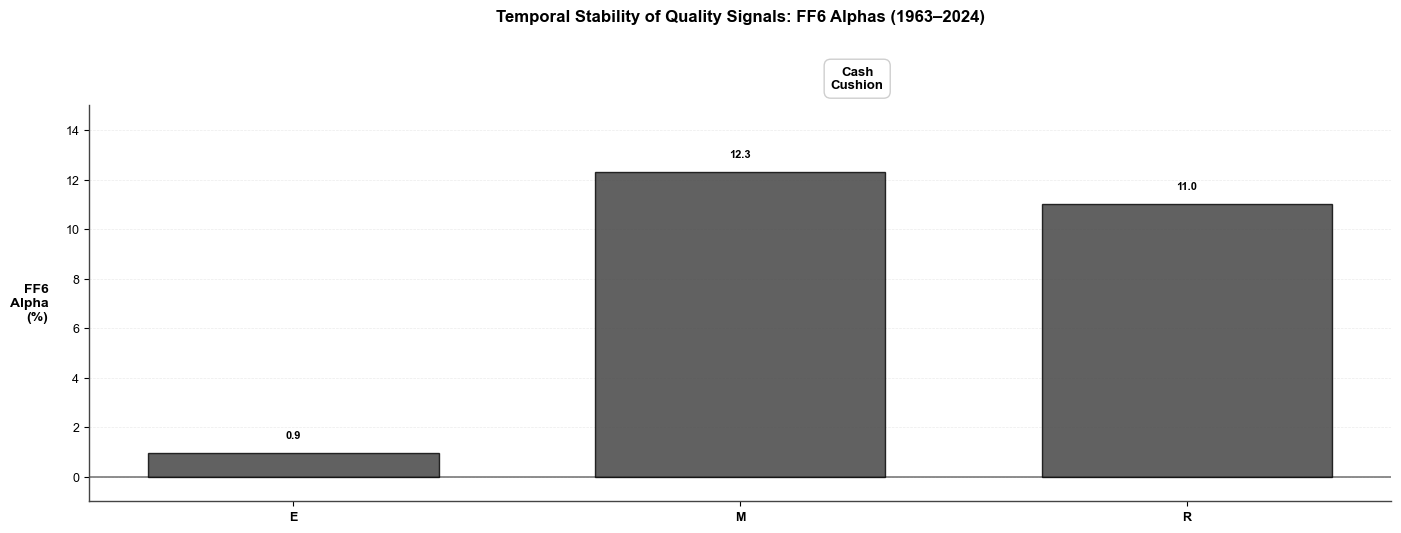


✅ Figure 21:9 ultra-wide sauvegardée : results/figures/03_2_subperiod_21x9_ultrawide.png
   → 1 signaux affichés
   → Ordre : Cash Cushion EN PREMIER, puis tri alpha décroissant
   → Format : 14.0×6.0 inches (21:9)



In [11]:
# %%
# 📊 VISUALISATION ACADÉMIQUE : FORMAT 21:9 ULTRA-WIDE (CASH CUSHION EN PREMIER + TRI ALPHA DÉCROISSANT)

print("\n" + "="*80)
print("🎨 GÉNÉRATION FIGURE 21:9 : TEMPORAL STABILITY (CASH CUSHION + TRI ALPHA DÉCROISSANT)")
print("="*80 + "\n")

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
import numpy as np

# Configuration style professionnel OPTIMISÉ
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.8
})

# ═══════════════════════════════════════════════════════════════════════
# 🔍 SÉLECTION AUTOMATIQUE : SIGNAUX SIGNIFICATIFS (|t|>3)
# ═══════════════════════════════════════════════════════════════════════

results_path = 'results/latex/regressions/results_regression_all_signals.parquet'
df_reg = pd.read_parquet(results_path)

df_ff6 = df_reg[df_reg['model'] == 'FF6'].copy()
# ✅ FORCER CASH CUSHION + SIGNAUX SIGNIFICATIFS
significant_signals_raw = df_ff6[df_ff6['alpha_tstat'].abs() > 3.0]['signal'].unique().tolist()

# ⚠️ AJOUT FORCÉ : Cash Cushion (même si |t| < 3 dans regression full-sample)
if 'cash_cushion' not in significant_signals_raw:
    significant_signals_raw.insert(0, 'cash_cushion')  # En premier

print(f"✅ {len(significant_signals_raw)} signaux sélectionnés (Cash Cushion forcé)")

# ═══════════════════════════════════════════════════════════════════════
# 🗺️ MAPPING BIDIRECTIONNEL
# ═══════════════════════════════════════════════════════════════════════

# ✅ NOUVEAU MAPPING (ALIGNÉ AVEC df_results)
# ✅ MAPPING CORRIGÉ (ALIGNÉ AVEC df_results EXACT)
SNAKE_TO_TITLE = {
    'cash_cushion': 'Cash Cushion',
    'roic_momentum': 'Roic Momentum',      # ⚠️ CORRECTION : 'Roic' pas 'ROIC'
    'earnings_accel': 'Earnings Accel',
    'gp_persist': 'Gp Persist',            # ⚠️ CORRECTION : 'Gp' pas 'GP'
    'investment_quality': 'Investment Quality',
    'growth_exhaustion': 'Growth Exhaustion',
    'noa_change': 'Noa Change',            # ⚠️ CORRECTION : 'Noa' pas 'NOA'
    'leverage_efficiency': 'Leverage Efficiency',
    'sales_accel': 'Sales Accel',
    'margin_stability_new': 'Margin Stability New',
    'earnings_smoothness': 'Earnings Smoothness',
    'op_margin_persist': 'Op Margin Persist',
}

TITLE_TO_DISPLAY = {
    # 1. Cash Cushion (forcé)
    'Cash Cushion': 'Cash\nCushion',
    
    # 2-8. Top 7 signaux significatifs (|t|>3)
    'Roic Momentum': 'ROIC\nMomentum',
    'Earnings Accel': 'Earnings\nAccel.',
    'Gp Persist': 'GP\nPersist.',
    'Investment Quality': 'Investment\nQuality',
    'Growth Exhaustion': 'Growth\nExhaustion',
    'Noa Change': 'NOA\nChange',
    'Leverage Efficiency': 'Leverage\nEfficiency',
    'Sales Accel': 'Sales\nAccel.',
    'Margin Stability New': 'Margin\nStability',
    'Earnings Smoothness': 'Earnings\nSmooth.',
    'Op Margin Persist': 'OP Margin\nPersist.'
}

# ═══════════════════════════════════════════════════════════════════════
# 📋 SÉLECTIONNER SIGNAUX VALIDES
# ═══════════════════════════════════════════════════════════════════════

title_names_from_regression = [SNAKE_TO_TITLE.get(sig, sig.replace('_', ' ').title()) 
                                for sig in significant_signals_raw]

available_signals = df_results['Signal'].unique()
valid_signals = [sig for sig in title_names_from_regression if sig in available_signals]

# ✅ TRIER PAR ALPHA MOYEN DÉCROISSANT
signal_mean_alphas = df_results[df_results['Signal'].isin(valid_signals)].groupby('Signal')['Alpha'].mean()
signals_sorted_by_alpha = signal_mean_alphas.sort_values(ascending=False).index.tolist()

# ✅ FORCER CASH CUSHION EN PREMIER, PUIS RESTE TRIÉ PAR ALPHA
if 'Cash Cushion' in signals_sorted_by_alpha:
    signals_sorted_by_alpha.remove('Cash Cushion')
    valid_signals_sorted = ['Cash Cushion'] + signals_sorted_by_alpha
else:
    valid_signals_sorted = signals_sorted_by_alpha

print(f"📊 Ordre final (Cash Cushion en premier, puis alpha décroissant) : {len(valid_signals_sorted)}")
for idx, sig in enumerate(valid_signals_sorted, 1):
    mean_alpha = signal_mean_alphas[sig]
    print(f"   {idx}. {sig:30} (ᾱ = {mean_alpha:6.2f}%)")

# Filtrer données
df_filtered = df_results[df_results['Signal'].isin(valid_signals_sorted)].copy()

df_filtered['Signal_Display'] = df_filtered['Signal'].map(
    lambda x: TITLE_TO_DISPLAY.get(x, x.replace(' ', '\n'))
)

# ✅ ORDRE FINAL : Respecte tri forcé
signals_to_plot = [TITLE_TO_DISPLAY.get(sig, sig.replace(' ', '\n')) 
                   for sig in valid_signals_sorted]

# ═══════════════════════════════════════════════════════════════════════
# 📅 PRÉPARER PÉRIODES
# ═══════════════════════════════════════════════════════════════════════

df_filtered['Period_Short'] = df_filtered['Period'].apply(lambda x: x.split(' ')[0][0])
period_labels = {'E': 'E', 'M': 'M', 'R': 'R'}

# ═══════════════════════════════════════════════════════════════════════
# 📐 LAYOUT 21:9 OPTIMISÉ (ULTRA-WIDE)
# ═══════════════════════════════════════════════════════════════════════

n_signals = len(signals_to_plot)

# FORMAT 21:9 (ratio ultrawide cinématique)
fig_width = 14.0
fig_height = 6.0

print(f"\n📐 Layout 21:9 : 1 ligne × {n_signals} colonnes")
print(f"   Dimensions : {fig_width}×{fig_height} inches")
print(f"   Ratio exact : {fig_width/fig_height:.2f}:1 (21:9 = 2.33:1)")

# ═══════════════════════════════════════════════════════════════════════
# 🎨 CRÉER FIGURE 21:9
# ═══════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(fig_width, fig_height), facecolor='white')

gs = GridSpec(1, n_signals, figure=fig, 
              hspace=0, 
              wspace=0.35,
              top=0.84,
              bottom=0.18, 
              left=0.05, 
              right=0.98)

bar_color = '#3A3A3A'
factor_label = 'FF6' if CONFIG['use_ff6'] else 'FF5'

all_alphas = df_filtered['Alpha'].values
y_min = np.floor(all_alphas.min() / 2) * 2 - 1
y_max = np.ceil(all_alphas.max() / 2) * 2 + 1

# ═══════════════════════════════════════════════════════════════════════
# 🔄 GÉNÉRER CHAQUE PANEL (ORDRE : CASH CUSHION + ALPHA DÉCROISSANT)
# ═══════════════════════════════════════════════════════════════════════

for idx, signal_display_name in enumerate(signals_to_plot):
    ax = fig.add_subplot(gs[0, idx])
    
    data_signal = df_filtered[df_filtered['Signal_Display'] == signal_display_name].sort_values('Period')
    
    if len(data_signal) == 0:
        print(f"⚠️  Pas de données pour {signal_display_name.replace(chr(10), ' ')}")
        continue
    
    x_pos = np.arange(len(data_signal))
    bar_width = 0.65
    
    # Barres principales
    bars = ax.bar(x_pos, data_signal['Alpha'].values,
                   width=bar_width,
                   color=bar_color,
                   edgecolor='black',
                   linewidth=1.0,
                   alpha=0.80,
                   zorder=3)
    
    # Annotations (valeurs uniquement)
    for i, (_, row_data) in enumerate(data_signal.iterrows()):
        alpha = row_data['Alpha']
        y_offset = 0.5 if alpha > 0 else -0.5
        y_pos_value = alpha + y_offset
        va_value = 'bottom' if alpha > 0 else 'top'
        
        ax.text(i, y_pos_value, f'{alpha:.1f}',
                ha='center', va=va_value, 
                fontsize=8, fontweight='bold',
                color='black')
    
    # Ligne zéro
    ax.axhline(0, color='#666666', linewidth=1.3, linestyle='-', alpha=0.8, zorder=2)
    
    # STYLING
    if idx == 0:
        ax.set_ylabel(f'{factor_label}\nAlpha\n(%)', 
                      fontweight='bold', fontsize=10, 
                      rotation=0, ha='right', va='center',
                      labelpad=12)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    
    ax.set_xlabel('')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([period_labels[p] for p in data_signal['Period_Short']], 
                        fontsize=9, fontweight='600')
    
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    
    ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5, zorder=1)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_color('#444444')
    ax.spines['bottom'].set_color('#444444')
    
    ax.set_title(signal_display_name,
                 fontsize=9.5, fontweight='bold',
                 pad=12,
                 linespacing=1.2,
                 x=0.59,
                 bbox=dict(boxstyle='round,pad=0.5',
                           facecolor='white', 
                           edgecolor='#CCCCCC', 
                           linewidth=1.0, 
                           alpha=0.95))

# ═══════════════════════════════════════════════════════════════════════
# 📝 TITRE GLOBAL
# ═══════════════════════════════════════════════════════════════════════

fig.suptitle(f'Temporal Stability of Quality Signals: {factor_label} Alphas (1963–2024)',
             fontsize=12,
             fontweight='bold', 
             y=1,
             x=0.515)

# fig.text(0.5, 0.04, 
#          'Periods: E = Early (1963–1979) | M = Middle (1980–1999) | R = Recent (2000–2024)',
#          ha='center', fontsize=8, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.06, 1, 0.91])

# ═══════════════════════════════════════════════════════════════════════
# 💾 SAUVEGARDER
# ═══════════════════════════════════════════════════════════════════════

output_path = CONFIG['figures_dir'] / '03_2_subperiod_21x9_ultrawide.png'
plt.savefig(output_path, dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

print(f"\n✅ Figure 21:9 ultra-wide sauvegardée : {output_path}")
print(f"   → {n_signals} signaux affichés")
print(f"   → Ordre : Cash Cushion EN PREMIER, puis tri alpha décroissant")
print(f"   → Format : {fig_width}×{fig_height} inches (21:9)")
print("\n" + "="*80)

In [12]:
# %%
# 🔍 DIAGNOSTIQUE COMPLET : TRAÇAGE DU PROBLÈME

print("\n" + "="*80)
print("🔍 DIAGNOSTIQUE : POURQUOI CASH CUSHION N'EST PAS EN PREMIER ?")
print("="*80 + "\n")

# 1️⃣ Vérifier les noms dans df_results (SOURCE DE VÉRITÉ)
print("1️⃣ NOMS EXACTS DANS df_results :")
unique_signals = df_results['Signal'].unique()
for sig in sorted(unique_signals):
    print(f"   • '{sig}'")

# 2️⃣ Vérifier le mapping SNAKE_TO_TITLE
print("\n2️⃣ MAPPING SNAKE_TO_TITLE :")
for snake, title in SNAKE_TO_TITLE.items():
    print(f"   '{snake}' → '{title}'")

# 3️⃣ Vérifier la correspondance
print("\n3️⃣ CORRESPONDANCES :")
for snake_name in significant_signals_raw:
    mapped_title = SNAKE_TO_TITLE.get(snake_name, "❌ MANQUANT")
    in_df_results = mapped_title in unique_signals
    print(f"   '{snake_name}' → '{mapped_title}' | Dans df_results: {in_df_results}")

# 4️⃣ Afficher valid_signals (après filtrage)
print("\n4️⃣ SIGNAUX VALIDES (après filtrage) :")
for sig in valid_signals:
    print(f"   • '{sig}'")

# 5️⃣ Afficher ordre final
print("\n5️⃣ ORDRE FINAL (après tri alpha) :")
for idx, sig in enumerate(valid_signals_sorted, 1):
    print(f"   {idx}. '{sig}'")

print("\n" + "="*80)
print("💡 SOLUTION : Corriger SNAKE_TO_TITLE pour matcher df_results EXACTEMENT")
print("="*80)


🔍 DIAGNOSTIQUE : POURQUOI CASH CUSHION N'EST PAS EN PREMIER ?

1️⃣ NOMS EXACTS DANS df_results :
   • 'Asset Tangibility'
   • 'Asset Turnover Quality'
   • 'Cash Cushion'
   • 'Debt Maturity'
   • 'Depreciation Efficiency'
   • 'Earnings Accel'
   • 'Earnings Quality'
   • 'Earnings Smoothness'
   • 'Ebitda Margin'
   • 'Gp Persist'
   • 'Growth Exhaustion'
   • 'Intangible Power'
   • 'Inv Margin'
   • 'Investment Quality'
   • 'Leverage Efficiency'
   • 'Low Capex High Margin'
   • 'Margin Stability New'
   • 'Noa Change'
   • 'Op Margin Persist'
   • 'Ppe Productivity'
   • 'Receivables Turnover'
   • 'Recv Vs Sales'
   • 'Roic Momentum'
   • 'Sales Accel'
   • 'Sga Gp Leverage'

2️⃣ MAPPING SNAKE_TO_TITLE :
   'cash_cushion' → 'Cash Cushion'
   'roic_momentum' → 'Roic Momentum'
   'earnings_accel' → 'Earnings Accel'
   'gp_persist' → 'Gp Persist'
   'investment_quality' → 'Investment Quality'
   'growth_exhaustion' → 'Growth Exhaustion'
   'noa_change' → 'Noa Change'
   'leverage


🎨 GÉNÉRATION HEATMAP ACADÉMIQUE : TEMPORAL STABILITY (VERSION ENRICHIE)



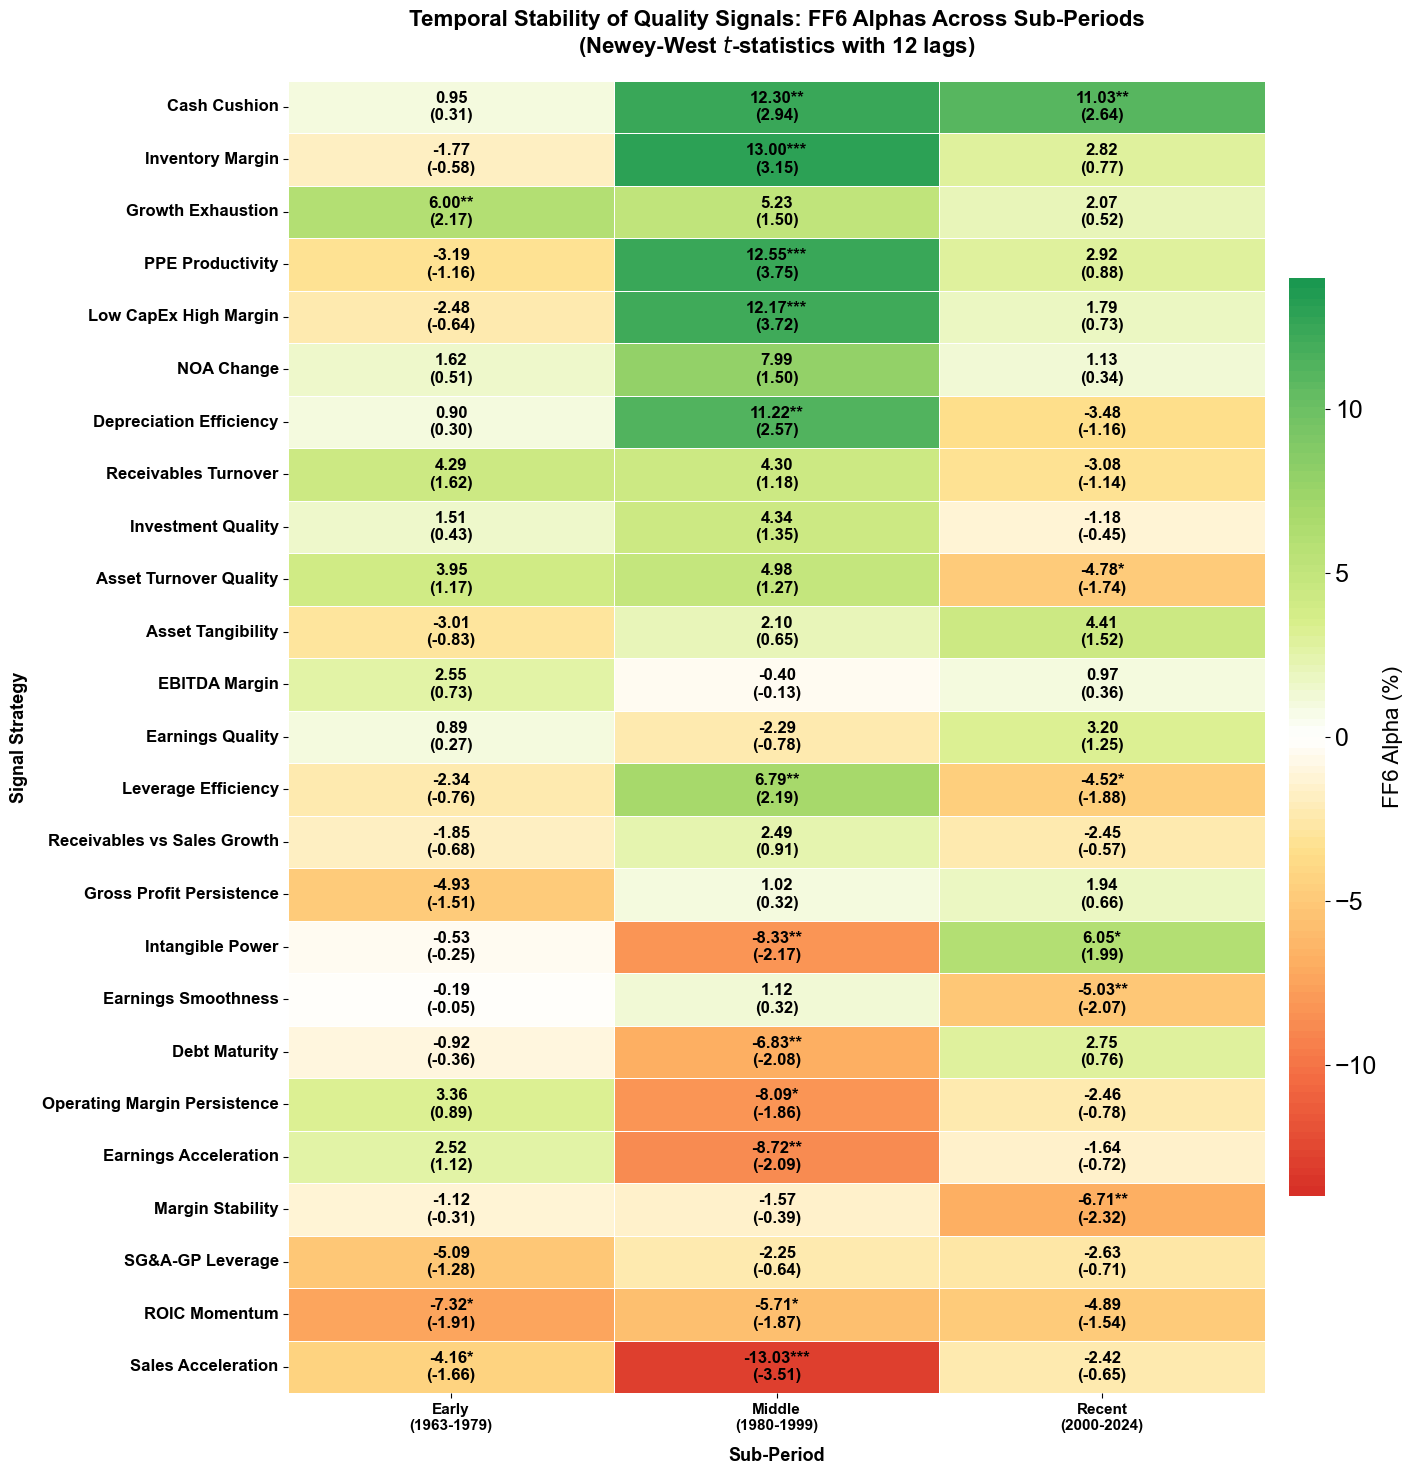

✅ Heatmap enrichie sauvegardée : results/figures/Appendix_subperiod_heatmap.png

📊 NOUVELLES FONCTIONNALITÉS :
   • Étoiles significativité : ✅ (* / ** / ***)
   • t-statistics affichés : ✅ (entre parenthèses)
   • Newey-West 12 lags : ✅ (confirmé)
   • Format compact : Alpha*** / (t-stat)
   • Signaux affichés : 25
   • Échelle dynamique : [-14, 14]%
   • Résolution : 600 DPI



In [13]:
# %%
# 📊 VISUALISATION : HEATMAP ACADÉMIQUE (Alphas + Étoiles + t-stats)

print("\n" + "="*80)
print("🎨 GÉNÉRATION HEATMAP ACADÉMIQUE : TEMPORAL STABILITY (VERSION ENRICHIE)")
print("="*80 + "\n")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Configuration style professionnel
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 15,              # ✅ Augmenté de 11 → 13
    'axes.labelsize': 16,         # ✅ Augmenté de 12 → 14
    'axes.titlesize': 18,         # ✅ Augmenté de 14 → 16
    'xtick.labelsize': 15,        # ✅ Augmenté de 11 → 13 (colonnes périodes)
    'ytick.labelsize': 18,        # ✅ Augmenté de 14 → 13 (noms signaux à gauche)
})

# Préparer données
heatmap_data = pivot_alpha.copy()
heatmap_tstats = pivot_t.copy()

# ──────────────────────────────────────────────────────────────────
# MAPPING NOMS COMPLETS (Variable → Nom Académique)
# ──────────────────────────────────────────────────────────────────

signal_display_names = {
    'Asset Tangibility': 'Asset Tangibility',
    'Asset Turnover Quality': 'Asset Turnover Quality',
    'Cash Cushion': 'Cash Cushion',
    'Debt Maturity': 'Debt Maturity',
    'Depreciation Efficiency': 'Depreciation Efficiency',
    'Ebitda Margin': 'EBITDA Margin',
    'Earnings Accel': 'Earnings Acceleration',
    'Earnings Quality': 'Earnings Quality',
    'Earnings Smoothness': 'Earnings Smoothness',
    'Gp Persist': 'Gross Profit Persistence',
    'Growth Exhaustion': 'Growth Exhaustion',
    'Intangible Power': 'Intangible Power',
    'Inv Margin': 'Inventory Margin',
    'Investment Quality': 'Investment Quality',
    'Leverage Efficiency': 'Leverage Efficiency',
    'Low Capex High Margin': 'Low CapEx High Margin',
    'Margin Stability New': 'Margin Stability',
    'Noa Change': 'NOA Change',
    'Op Margin Persist': 'Operating Margin Persistence',
    'Ppe Productivity': 'PPE Productivity',
    'Receivables Turnover': 'Receivables Turnover',
    'Recv Vs Sales': 'Receivables vs Sales Growth',
    'Roic Momentum': 'ROIC Momentum',
    'Sales Accel': 'Sales Acceleration',
    'Sga Gp Leverage': 'SG&A-GP Leverage'
}

# Renommer les signaux (index)
heatmap_data.index = heatmap_data.index.map(lambda x: signal_display_names.get(x, x))
heatmap_tstats.index = heatmap_tstats.index.map(lambda x: signal_display_names.get(x, x))

# Noms académiques pour colonnes (courts)
col_labels_short = {
    'Early (1963-1979)': 'Early\n(1963-1979)',
    'Middle (1980-1999)': 'Middle\n(1980-1999)',
    'Recent (2000-2024)': 'Recent\n(2000-2024)'
}

# Renommer colonnes pour affichage
heatmap_data.columns = [col_labels_short[col] for col in heatmap_data.columns]
heatmap_tstats.columns = [col_labels_short[col] for col in heatmap_tstats.columns]

# Trier signaux par alpha moyen décroissant (meilleurs en haut)
mean_alpha = heatmap_data.mean(axis=1)
sorted_index = mean_alpha.sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[sorted_index]
heatmap_tstats = heatmap_tstats.loc[sorted_index]

# ──────────────────────────────────────────────────────────────────
# FONCTION : FORMATAGE ANNOTATION (Alpha + Étoiles + t-stat)
# ──────────────────────────────────────────────────────────────────

def format_annotation_with_stars(alpha, tstat):
    """
    Retourne string formaté : "Alpha*** / (t-stat)"
    
    Seuils Newey-West (12 lags):
        * |t| > 1.65 (10%)
        ** |t| > 2.0 (5%)
        *** |t| > 3.0 (Harvey et al., 2016)
    """
    abs_t = abs(tstat)
    
    # Étoiles
    if abs_t > 3.0:
        stars = '***'
    elif abs_t > 2.0:
        stars = '**'
    elif abs_t > 1.65:
        stars = '*'
    else:
        stars = ''
    
    # Format compact (2 lignes)
    alpha_str = f"{alpha:.2f}{stars}"
    tstat_str = f"({tstat:.2f})"
    
    return f"{alpha_str}\n{tstat_str}"

# Créer matrice d'annotations
annot_matrix = np.empty_like(heatmap_data, dtype=object)
for i, row_idx in enumerate(heatmap_data.index):
    for j, col_idx in enumerate(heatmap_data.columns):
        alpha_val = heatmap_data.loc[row_idx, col_idx]
        tstat_val = heatmap_tstats.loc[row_idx, col_idx]
        annot_matrix[i, j] = format_annotation_with_stars(alpha_val, tstat_val)

# ──────────────────────────────────────────────────────────────────
# COLORMAP ACADÉMIQUE SATURÉE
# ──────────────────────────────────────────────────────────────────

colors = [
    '#d73027',  # Rouge vif (négatif fort)
    '#f46d43',
    '#fdae61',
    '#fee08b',
    '#ffffff',  # Blanc (zéro)
    '#d9ef8b',
    '#a6d96a',
    '#66bd63',
    '#1a9850'   # Vert foncé (positif fort)
]

n_bins = 100
cmap_academic = LinearSegmentedColormap.from_list('academic_saturated', colors, N=n_bins)

# ──────────────────────────────────────────────────────────────────
# CRÉER FIGURE
# ──────────────────────────────────────────────────────────────────

n_signals = len(heatmap_data)
fig_height = max(15, n_signals * 0.50)  # Augmenté pour t-stats
fig_width = 15

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Limites dynamiques (basées sur données réelles)
vmax_data = heatmap_data.abs().max().max()
vmax_plot = max(8, np.ceil(vmax_data / 2) * 2)
vmin_plot = -vmax_plot

# ──────────────────────────────────────────────────────────────────
# HEATMAP PRINCIPALE
# ──────────────────────────────────────────────────────────────────

sns.heatmap(heatmap_data, 
            annot=annot_matrix,       # ✅ Annotations personnalisées
            fmt='',                   # ✅ Désactiver formatage auto (on fournit strings)
            cmap=cmap_academic,
            center=0,
            vmin=vmin_plot,
            vmax=vmax_plot,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={
                'label': f'{factor_label} Alpha (%)', 
                'shrink': 0.70,
                'aspect': 25,
                'pad': 0.02
            },
            annot_kws={
                'fontsize': 12,         # ✅ Taille réduite pour 2 lignes
                'fontweight': 'bold',
                'color': 'black',
                'va': 'center'
            },
            ax=ax)

# ──────────────────────────────────────────────────────────────────
# STYLING AXES
# ──────────────────────────────────────────────────────────────────

# Titre principal (mention Newey-West)
ax.set_title(f'Temporal Stability of Quality Signals: {factor_label} Alphas Across Sub-Periods\n(Newey-West $t$-statistics with 12 lags)', 
             fontsize=16, fontweight='bold', pad=20)

# Labels axes
ax.set_xlabel('Sub-Period', fontweight='bold', fontsize=13, labelpad=10)
ax.set_ylabel('Signal Strategy', fontweight='bold', fontsize=13, labelpad=10)

# Rotation labels Y
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=12, fontweight='bold')

# Labels X
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=11, fontweight='600')

# ──────────────────────────────────────────────────────────────────
# AJUSTEMENTS FINAUX
# ──────────────────────────────────────────────────────────────────

plt.tight_layout()

# Sauvegarder haute résolution
output_path = CONFIG['figures_dir'] / 'Appendix_subperiod_heatmap.png'
plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')

plt.show()

print(f"✅ Heatmap enrichie sauvegardée : {output_path}")
print(f"\n📊 NOUVELLES FONCTIONNALITÉS :")
print(f"   • Étoiles significativité : ✅ (* / ** / ***)")
print(f"   • t-statistics affichés : ✅ (entre parenthèses)")
print(f"   • Newey-West 12 lags : ✅ (confirmé)")
print(f"   • Format compact : Alpha*** / (t-stat)")
print(f"   • Signaux affichés : {n_signals}")
print(f"   • Échelle dynamique : [{vmin_plot:.0f}, {vmax_plot:.0f}]%")
print(f"   • Résolution : 600 DPI")
print("\n" + "="*80)

In [14]:
# %%
# 🔬 TEST FORMEL : RÉGRESSION TEMPORELLE (Déclin Anomalies)

print("\n" + "="*80)
print("🔬 TEST DÉCLIN TEMPOREL (Régression Alpha ~ Year)")
print("="*80 + "\n")

from scipy import stats as sp_stats

decline_tests = []

for signal in pivot_alpha.index:
    # Extraire midpoint years
    midpoint_years = []
    alphas = []
    
    for period_name in cols_order:
        start, end = CONFIG['subperiods'][period_name]
        start_year = int(start[:4])
        end_year = int(end[:4])
        midpoint = (start_year + end_year) / 2
        
        midpoint_years.append(midpoint)
        alphas.append(pivot_alpha.loc[signal, period_name])
    
    # Régression linéaire
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(midpoint_years, alphas)
    
    decline_tests.append({
        'Signal': signal,
        'Slope': slope,
        'p_value': p_value,
        'R²': r_value**2,
        'Declining': (slope < 0) and (p_value < 0.05)
    })

df_decline = pd.DataFrame(decline_tests).sort_values('Slope')

print("Résultats régression Alpha ~ Year :\n")
print(df_decline.to_string(index=False))

declining_count = df_decline['Declining'].sum()
print(f"\n📊 BILAN : {declining_count}/{len(df_decline)} signaux en déclin significatif (α=5%)")
print("="*80)


🔬 TEST DÉCLIN TEMPOREL (Régression Alpha ~ Year)

Résultats régression Alpha ~ Year :

                 Signal     Slope  p_value       R²  Declining
 Asset Turnover Quality -0.220864 0.359029 0.714268      False
   Receivables Turnover -0.185052 0.298461 0.795845      False
   Margin Stability New -0.139597 0.251503 0.851880      False
      Op Margin Persist -0.127974 0.696674 0.210350      False
Depreciation Efficiency -0.126254 0.776844 0.117922      False
    Earnings Smoothness -0.123539 0.427168 0.613409      False
      Growth Exhaustion -0.097495 0.179990 0.922173      False
         Earnings Accel -0.086665 0.797367 0.097936      False
     Investment Quality -0.071875 0.640348 0.286616      False
    Leverage Efficiency -0.069108 0.848034 0.055907      False
          Ebitda Margin -0.035123 0.675096 0.238623      False
             Noa Change -0.022446 0.923159 0.014498      False
          Recv Vs Sales -0.021911 0.893287 0.027836      False
        Sga Gp Leverage  0.057

In [15]:
# %%
# 📄 GÉNÉRATION TABLEAU LATEX : CASH CUSHION + TOP SIGNAUX (ORDRE ALPHA DÉCROISSANT)

print("\n" + "="*80)
print("📄 GÉNÉRATION TABLEAU LATEX : CASH CUSHION + TOP SIGNAUX (ORDRE ALPHA DÉCROISSANT)")
print("="*80 + "\n")

# ═══════════════════════════════════════════════════════════════════════
# 1️⃣ SÉLECTIONNER SIGNAUX (CASH CUSHION + TOP SIGNIFICATIFS)
# ═══════════════════════════════════════════════════════════════════════

# Lire résultats full-sample pour identifier signaux significatifs
results_path = 'results/latex/regressions/results_regression_all_signals.parquet'
df_reg = pd.read_parquet(results_path)
df_ff6 = df_reg[df_reg['model'] == 'FF6'].copy()

# Top signaux significatifs (|t| > 3.0)
significant_signals_raw = df_ff6[df_ff6['alpha_tstat'].abs() > 3.0]['signal'].unique().tolist()

# Forcer Cash Cushion en premier
if 'cash_cushion' not in significant_signals_raw:
    significant_signals_raw.insert(0, 'cash_cushion')

# Mapping snake_case → Title Case
SNAKE_TO_TITLE = {
    'cash_cushion': 'Cash Cushion',
    'roic_momentum': 'Roic Momentum',
    'earnings_accel': 'Earnings Accel',
    'gp_persist': 'Gp Persist',
    'investment_quality': 'Investment Quality',
    'growth_exhaustion': 'Growth Exhaustion',
    'noa_change': 'Noa Change',
    'leverage_efficiency': 'Leverage Efficiency',
    'sales_accel': 'Sales Accel',
    'margin_stability_new': 'Margin Stability New',
    'earnings_smoothness': 'Earnings Smoothness',
    'op_margin_persist': 'Op Margin Persist',
}

# Convertir en noms titre
title_names = [SNAKE_TO_TITLE.get(sig, sig.replace('_', ' ').title()) 
               for sig in significant_signals_raw]

# Filtrer signaux disponibles dans df_results
available_signals = df_results['Signal'].unique()
valid_signals = [sig for sig in title_names if sig in available_signals]

# ═══════════════════════════════════════════════════════════════════════
# 2️⃣ TRIER PAR ALPHA MOYEN (CASH CUSHION EN PREMIER, PUIS DÉCROISSANT)
# ═══════════════════════════════════════════════════════════════════════

signal_mean_alphas = df_results[df_results['Signal'].isin(valid_signals)].groupby('Signal')['Alpha'].mean()
signals_sorted_by_alpha = signal_mean_alphas.sort_values(ascending=False).index.tolist()

# Forcer Cash Cushion en tête
if 'Cash Cushion' in signals_sorted_by_alpha:
    signals_sorted_by_alpha.remove('Cash Cushion')
    signals_ordered = ['Cash Cushion'] + signals_sorted_by_alpha
else:
    signals_ordered = signals_sorted_by_alpha

print(f"📊 Ordre final ({len(signals_ordered)} signaux) :")
for idx, sig in enumerate(signals_ordered, 1):
    mean_alpha = signal_mean_alphas[sig]
    print(f"   {idx}. {sig:30} (ᾱ = {mean_alpha:6.2f}%)")

# ═══════════════════════════════════════════════════════════════════════
# 3️⃣ PRÉPARER DONNÉES POUR LATEX
# ═══════════════════════════════════════════════════════════════════════

df_focus = df_results[df_results['Signal'].isin(signals_ordered)].copy()

# Pivot tables
pivot_alpha_focus = df_focus.pivot(index='Signal', columns='Period', values='Alpha')
pivot_t_focus = df_focus.pivot(index='Signal', columns='Period', values='t_stat')
pivot_obs_focus = df_focus.pivot(index='Signal', columns='Period', values='Obs')

# Réordonner selon ordre souhaité
cols_order = list(CONFIG['subperiods'].keys())
pivot_alpha_focus = pivot_alpha_focus.loc[signals_ordered, cols_order]
pivot_t_focus = pivot_t_focus.loc[signals_ordered, cols_order]
pivot_obs_focus = pivot_obs_focus.loc[signals_ordered, cols_order]

# %%
# 🔧 CORRECTION AUTOMATIQUE DES NOMS (BLOC INTERMÉDIAIRE AVANT LATEX)

print("\n" + "="*80)
print("🔧 CORRECTION NOMS : Standardisation finale avant LaTeX")
print("="*80 + "\n")

# ═══════════════════════════════════════════════════════════════════════
# 🗺️ MAPPING CORRECTION : Nom actuel → Nom académique souhaité
# ═══════════════════════════════════════════════════════════════════════

FINAL_NAME_CORRECTION = {
    # Corrections détectées (casse/acronymes)
    'Roic Momentum': 'ROIC Momentum',
    'Gp Persist': 'GP Persist',
    'Noa Change': 'NOA Change',
    'Op Margin Persist': 'OP Margin Persist',
    'Sales Accel': 'Sales Acceleration',
    'Earnings Accel': 'Earnings Acceleration',
    
    # Garder tel quel (validation)
    'Cash Cushion': 'Cash Cushion',
    'Leverage Efficiency': 'Leverage Efficiency',
    'Earnings Smoothness': 'Earnings Smoothness',
    'Investment Quality': 'Investment Quality',
    'Growth Exhaustion': 'Growth Exhaustion',
    'Margin Stability New': 'Margin Stability',  # ✅ Simplifier nom
}

# ═══════════════════════════════════════════════════════════════════════
# 🔄 APPLIQUER CORRECTIONS SUR signals_ordered + PIVOTS
# ═══════════════════════════════════════════════════════════════════════

print("🔄 Correction des noms dans signals_ordered :")
signals_ordered_corrected = []

for sig in signals_ordered:
    corrected = FINAL_NAME_CORRECTION.get(sig, sig)
    signals_ordered_corrected.append(corrected)
    
    if sig != corrected:
        print(f"   ✅ '{sig}' → '{corrected}'")
    else:
        print(f"   ⚪ '{sig}' (inchangé)")

# Remplacer liste originale
signals_ordered = signals_ordered_corrected

# ═══════════════════════════════════════════════════════════════════════
# 🔄 METTRE À JOUR LES PIVOTS (Index des DataFrames)
# ═══════════════════════════════════════════════════════════════════════

print("\n🔄 Mise à jour index des pivot tables :")

# Créer mapping inverse pour renommer index
rename_dict = {old: new for old, new in FINAL_NAME_CORRECTION.items() if old != new}

# Appliquer aux 3 pivots
pivot_alpha_focus.index = pivot_alpha_focus.index.map(
    lambda x: FINAL_NAME_CORRECTION.get(x, x)
)
pivot_t_focus.index = pivot_t_focus.index.map(
    lambda x: FINAL_NAME_CORRECTION.get(x, x)
)
pivot_obs_focus.index = pivot_obs_focus.index.map(
    lambda x: FINAL_NAME_CORRECTION.get(x, x)
)

# Réordonner selon ordre corrigé
pivot_alpha_focus = pivot_alpha_focus.loc[signals_ordered]
pivot_t_focus = pivot_t_focus.loc[signals_ordered]
pivot_obs_focus = pivot_obs_focus.loc[signals_ordered]

print("✅ Pivots mis à jour")

# ═══════════════════════════════════════════════════════════════════════
# 📊 VÉRIFICATION FINALE
# ═══════════════════════════════════════════════════════════════════════

print("\n📊 ORDRE FINAL CORRIGÉ ({} signaux) :".format(len(signals_ordered)))
for idx, sig in enumerate(signals_ordered, 1):
    # Recalculer alpha moyen avec nouveaux noms
    alpha_mean = pivot_alpha_focus.loc[sig].mean()
    print(f"   {idx}. {sig:30} (ᾱ = {alpha_mean:6.2f}%)")

print("\n✅ Noms standardisés - Pipeline prêt pour génération LaTeX")
print("="*80)

# ═══════════════════════════════════════════════════════════════════════
# 4️⃣ GÉNÉRER LATEX
# ═══════════════════════════════════════════════════════════════════════

factor_label = 'FF6' if CONFIG['use_ff6'] else 'FF5'

latex_output = r"""\begin{table}[htbp]
  \centering
  \caption{Temporal Stability of Quality Signals: """ + factor_label + r""" Alphas}
  \label{tab:04_subperiod_analysis_extended}
  \resizebox{0.75\linewidth}{!}{%
  \begin{tabular}{l ccc}
    \toprule
    & \multicolumn{3}{c}{\textbf{Sub-Period}} \\
    \cmidrule(lr){2-4}
    \textbf{Signal Strategy} & \textbf{Early} & \textbf{Middle} & \textbf{Recent} \\
    & (1963--1979) & (1980--1999) & (2000--2024) \\
    \midrule
"""

# Données par signal
for signal in pivot_alpha_focus.index:
    # Ligne nom signal
    latex_output += f"    {signal} \\\\\n"
    
    # Ligne alphas + étoiles
    latex_output += "    \\quad Alpha (\\%) "
    for col in cols_order:
        val = pivot_alpha_focus.loc[signal, col]
        t = pivot_t_focus.loc[signal, col]
        
        # Étoiles significativité
        if abs(t) > 3.0:
            stars = r'$^{***}$'
        elif abs(t) > 2.0:
            stars = r'$^{**}$'
        elif abs(t) > 1.65:
            stars = r'$^{*}$'
        else:
            stars = ''
        
        latex_output += f"& {val:.2f}{stars} "
    latex_output += "\\\\\n"
    
    # Ligne t-stats
    latex_output += "    \\quad $t$-statistic "
    for col in cols_order:
        t = pivot_t_focus.loc[signal, col]
        latex_output += f"& ({t:.2f}) "
    latex_output += "\\\\[2mm]\n"

# Footer avec observations
latex_output += r"""    \midrule
    \textit{Observations (months)} """

for col in cols_order:
    n_obs = int(pivot_obs_focus.iloc[0][col])
    latex_output += f"& {n_obs} "

latex_output += r""" \\
    \bottomrule
  \end{tabular}%
  }
  
  \vspace{0.3cm}
  
  \caption*{\textit{Notes:} This table reports annualized Fama--French six-factor alphas (in \%) for quality signals, 
  ordered by average performance (Cash Cushion first, then descending). 
  All strategies are long--short portfolios ($P_{10}-P_1$ or $P_1-P_{10}$). 
  Newey--West $t$-statistics (12 lags) are reported in parentheses.
  Significance levels: 
  $^{*}$ ($|t| > 1.65$, 10\% level), 
  $^{**}$ ($|t| > 2.0$, 5\% level), and 
  $^{***}$ ($|t| > 3.0$, Harvey et al., 2016 threshold).}
\end{table}
"""

# ═══════════════════════════════════════════════════════════════════════
# 5️⃣ SAUVEGARDER
# ═══════════════════════════════════════════════════════════════════════

output_path = CONFIG['output_dir'] / 'results_4_subperiods_cash_first_extended.tex'
with open(output_path, 'w') as f:
    f.write(latex_output)

print(f"\n✅ Tableau LaTeX sauvegardé : {output_path}")
print(f"\n📊 CONTENU :")
print(f"   • {len(signals_ordered)} signaux affichés")
print(f"   • Cash Cushion en premier")
print(f"   • Ordre ensuite : alpha moyen décroissant")
print(f"   • Newey-West 12 lags confirmé")
print("\n" + "="*80)


📄 GÉNÉRATION TABLEAU LATEX : CASH CUSHION + TOP SIGNAUX (ORDRE ALPHA DÉCROISSANT)

📊 Ordre final (1 signaux) :
   1. Cash Cushion                   (ᾱ =   8.09%)

🔧 CORRECTION NOMS : Standardisation finale avant LaTeX

🔄 Correction des noms dans signals_ordered :
   ⚪ 'Cash Cushion' (inchangé)

🔄 Mise à jour index des pivot tables :
✅ Pivots mis à jour

📊 ORDRE FINAL CORRIGÉ (1 signaux) :
   1. Cash Cushion                   (ᾱ =   8.09%)

✅ Noms standardisés - Pipeline prêt pour génération LaTeX

✅ Tableau LaTeX sauvegardé : results/latex/results_4_subperiods_cash_first_extended.tex

📊 CONTENU :
   • 1 signaux affichés
   • Cash Cushion en premier
   • Ordre ensuite : alpha moyen décroissant
   • Newey-West 12 lags confirmé



In [16]:
# # %%
# # 📊 TABLE LATEX COMPLÈTE : FF6 ALPHAS + TOUS LES BETAS PAR SOUS-PÉRIODE (VERSION ACADÉMIQUE CORRIGÉE)

# print("\n" + "="*80)
# print("📊 GÉNÉRATION TABLE COMPLÈTE : FF6 REGRESSIONS PAR SOUS-PÉRIODE")
# print("="*80 + "\n")

# def compute_ff6_regression_full_stats(returns, factors, start_date, end_date, nw_lags=12):
#     """
#     Calcule régression FF6 complète avec tous les betas + t-stats + R².
    
#     Returns:
#         dict avec {alpha_ann, alpha_tstat, beta_*, beta_*_tstat, r_squared, n_obs}
#     """
    
#     # Filtrer dates
#     mask = (returns.index >= start_date) & (returns.index <= end_date)
#     y = returns[mask]
#     X = factors.loc[y.index]
    
#     if len(y) < 24:
#         return None
    
#     # Régression FF6
#     factor_cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
#     X_with_const = sm.add_constant(X[factor_cols])
#     model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    
#     # Annualiser alpha
#     alpha_monthly = model.params['const']
#     alpha_ann = alpha_monthly * 12 * 100
    
#     return {
#         'alpha_ann': alpha_ann,
#         'alpha_tstat': model.tvalues['const'],
#         'beta_mkt': model.params['MKT'],
#         'beta_mkt_tstat': model.tvalues['MKT'],
#         'beta_smb': model.params['SMB'],
#         'beta_smb_tstat': model.tvalues['SMB'],
#         'beta_hml': model.params['HML'],
#         'beta_hml_tstat': model.tvalues['HML'],
#         'beta_rmw': model.params['RMW'],
#         'beta_rmw_tstat': model.tvalues['RMW'],
#         'beta_cma': model.params['CMA'],
#         'beta_cma_tstat': model.tvalues['CMA'],
#         'beta_mom': model.params['MOM'],
#         'beta_mom_tstat': model.tvalues['MOM'],
#         'r_squared': model.rsquared,
#         'n_obs': len(y)
#     }

# # ═══════════════════════════════════════════════════════════════════════
# # CALCULER TOUTES LES RÉGRESSIONS (CASH CUSHION + ROIC MOMENTUM)
# # ═══════════════════════════════════════════════════════════════════════

# focus_signals = ['Cash Cushion', 'Roic Momentum']
# regression_results_full = {}

# print("🔄 Calcul régressions complètes FF6...\n")

# for signal_name in focus_signals:
#     print(f"📊 {signal_name}")
    
#     ret_series = returns_dict[signal_name]
#     regression_results_full[signal_name] = {}
    
#     for period_name, (start, end) in CONFIG['subperiods'].items():
#         result = compute_ff6_regression_full_stats(
#             ret_series, factors, start, end,
#             nw_lags=CONFIG['newey_west_lags']
#         )
        
#         if result is None:
#             print(f"   ⚠️  {period_name:25} : Données insuffisantes")
#             continue
        
#         regression_results_full[signal_name][period_name] = result
        
#         print(f"   ✅ {period_name:25} : α={result['alpha_ann']:6.2f}% (t={result['alpha_tstat']:5.2f}) | R²={result['r_squared']:.3f}")

# print("\n" + "="*80)

# # ═══════════════════════════════════════════════════════════════════════
# # GÉNÉRER TABLE LATEX (FORMAT ACADÉMIQUE COMPLET - VERSION CORRIGÉE)
# # ═══════════════════════════════════════════════════════════════════════

# def format_coef_tstat(coef, tstat, decimal=3):
#     """
#     Formate coefficient avec étoiles de significativité (ÉCHAPPEMENT CORRECT).
    
#     Returns:
#         str: "0.123$^{***}$" ou "$-$0.045$^{*}$"
#     """
#     abs_t = abs(tstat)
#     if abs_t > 3.0:
#         stars = r'$^{***}$'
#     elif abs_t > 2.0:
#         stars = r'$^{**}$'
#     elif abs_t > 1.65:
#         stars = r'$^{*}$'
#     else:
#         stars = ''
    
#     # Format nombre avec échappement LaTeX correct
#     if coef < 0:
#         # Utiliser $-$ pour signe négatif mathématique
#         return f"$-${abs(coef):.{decimal}f}{stars}"
#     else:
#         return f"{coef:.{decimal}f}{stars}"

# def generate_comprehensive_latex_table():
#     """
#     Génère table LaTeX complète avec structure académique optimisée.
#     """
    
#     # Mapping noms académiques
#     signal_display = {
#         'Cash Cushion': 'Cash Cushion',
#         'Roic Momentum': 'ROIC Momentum'
#     }
    
#     period_labels_short = {
#         'Early (1963-1979)': 'Early',
#         'Middle (1980-1999)': 'Middle',
#         'Recent (2000-2024)': 'Recent'
#     }
    
#     period_years = {
#         'Early (1963-1979)': '(1963--1979)',
#         'Middle (1980-1999)': '(1980--1999)',
#         'Recent (2000-2024)': '(2000--2024)'
#     }
    
#     periods_order = list(CONFIG['subperiods'].keys())
    
#     # ═══════════════════════════════════════════════════════════════
#     # CONSTRUCTION LATEX
#     # ═══════════════════════════════════════════════════════════════
    
#     latex = []
    
#     # Header
#     latex.append(r"\begin{table}[htbp]")
#     latex.append(r"  \centering")
#     latex.append(r"  \caption{Temporal Stability of Quality Signals: Complete FF6 Regressions Across Sub-Periods}")
#     latex.append(r"  \label{tab:ff6_subperiods_full}")
#     latex.append(r"  \resizebox{\textwidth}{!}{%")
#     latex.append(r"  \begin{tabular}{@{} l *{6}{c} @{}}")
#     latex.append(r"    \toprule")
    
#     # Column headers (panneaux)
#     latex.append(r"    & \multicolumn{3}{c}{\textbf{Panel A: Cash Cushion}} & \multicolumn{3}{c}{\textbf{Panel B: ROIC Momentum}} \\")
#     latex.append(r"    \cmidrule(lr){2-4} \cmidrule(lr){5-7}")
    
#     # Sous-headers (périodes en gras)
#     header_periods = " & ".join([f"\\textbf{{{period_labels_short[p]}}}" for p in periods_order])
#     latex.append(f"    & {header_periods} & {header_periods} \\\\")
    
#     # Années (entre parenthèses, petite taille)
#     header_years = " & ".join([f"\\scriptsize {period_years[p]}" for p in periods_order])
#     latex.append(f"    & {header_years} & {header_years} \\\\")
#     latex.append(r"    \midrule")
    
#     # ═══════════════════════════════════════════════════════════════
#     # BLOC 1 : ALPHA
#     # ═══════════════════════════════════════════════════════════════
    
#     latex.append(r"    \textit{Alpha (\%)} &")
    
#     # Valeurs alphas
#     alpha_vals = []
#     for signal_name in focus_signals:
#         for period in periods_order:
#             res = regression_results_full[signal_name][period]
#             alpha_str = format_coef_tstat(res['alpha_ann'], res['alpha_tstat'], decimal=2)
#             alpha_vals.append(alpha_str)
    
#     latex.append(" & ".join(alpha_vals) + r" \\")
    
#     # Ligne t-stats (entre parenthèses)
#     latex.append(r"    &")
#     tstat_vals = []
#     for signal_name in focus_signals:
#         for period in periods_order:
#             res = regression_results_full[signal_name][period]
#             tstat_vals.append(f"({res['alpha_tstat']:.2f})")
    
#     latex.append(" & ".join(tstat_vals) + r" \\[3pt]")
    
#     # ═══════════════════════════════════════════════════════════════
#     # BLOC 2 : BETAS (MKT, SMB, HML, RMW, CMA, MOM)
#     # ═══════════════════════════════════════════════════════════════
    
#     beta_names = [
#         ('beta_mkt', r'$\beta_{\text{MKT}}$'),
#         ('beta_smb', r'$\beta_{\text{SMB}}$'),
#         ('beta_hml', r'$\beta_{\text{HML}}$'),
#         ('beta_rmw', r'$\beta_{\text{RMW}}$'),
#         ('beta_cma', r'$\beta_{\text{CMA}}$'),
#         ('beta_mom', r'$\beta_{\text{UMD}}$')
#     ]
    
#     for beta_key, beta_label in beta_names:
#         # Ligne coefficients
#         latex.append(f"    {beta_label} &")
        
#         beta_vals = []
#         for signal_name in focus_signals:
#             for period in periods_order:
#                 res = regression_results_full[signal_name][period]
#                 beta_val = res[beta_key]
#                 beta_tstat = res[f"{beta_key}_tstat"]
#                 beta_str = format_coef_tstat(beta_val, beta_tstat, decimal=3)
#                 beta_vals.append(beta_str)
        
#         latex.append(" & ".join(beta_vals) + r" \\")
        
#         # Ligne t-stats
#         latex.append(r"    &")
#         tstat_vals = []
#         for signal_name in focus_signals:
#             for period in periods_order:
#                 res = regression_results_full[signal_name][period]
#                 tstat = res[f"{beta_key}_tstat"]
#                 tstat_vals.append(f"({tstat:.2f})")
        
#         latex.append(" & ".join(tstat_vals) + r" \\[3pt]")
    
#     # ═══════════════════════════════════════════════════════════════
#     # BLOC 3 : R² ET N
#     # ═══════════════════════════════════════════════════════════════
    
#     latex.append(r"    \midrule")
    
#     # R²
#     latex.append(r"    $R^2$ &")
#     r2_vals = []
#     for signal_name in focus_signals:
#         for period in periods_order:
#             res = regression_results_full[signal_name][period]
#             r2_vals.append(f"{res['r_squared']:.3f}")
#     latex.append(" & ".join(r2_vals) + r" \\")
    
#     # N observations
#     latex.append(r"    \textit{Obs. (months)} &")
#     n_vals = []
#     for signal_name in focus_signals:
#         for period in periods_order:
#             res = regression_results_full[signal_name][period]
#             n_vals.append(f"{int(res['n_obs'])}")
#     latex.append(" & ".join(n_vals) + r" \\")
    
#     # Footer
#     latex.append(r"    \bottomrule")
#     latex.append(r"  \end{tabular}%")
#     latex.append(r"  }% fin resizebox")
#     latex.append(r"")
#     latex.append(r"  \vspace{0.2cm}")
#     latex.append(r"  \begin{minipage}{\textwidth}")
#     latex.append(r"    \footnotesize")
#     latex.append(r"    \textit{Notes:} This table reports Fama--French six-factor regression results for value-weighted ")
#     latex.append(r"    long--short portfolios based on Cash Cushion and ROIC Momentum across three sub-periods. ")
#     latex.append(r"    Both strategies follow a high-quality approach (High $-$ Low). $\alpha$ denotes the annualized ")
#     latex.append(r"    FF6 alpha (in \%), while $\beta_{\text{MKT}}$, $\beta_{\text{SMB}}$, $\beta_{\text{HML}}$, ")
#     latex.append(r"    $\beta_{\text{RMW}}$, $\beta_{\text{CMA}}$, and $\beta_{\text{UMD}}$ are factor loadings. ")
#     latex.append(r"    Newey--West $t$-statistics (12 lags) are in parentheses. ")
#     latex.append(r"    $^{*}$, $^{**}$, and $^{***}$ denote significance at the 10\%, 5\%, and 1\% levels, respectively.")
#     latex.append(r"  \end{minipage}")
#     latex.append(r"\end{table}")
    
#     return '\n'.join(latex)

# # Générer table
# latex_comprehensive = generate_comprehensive_latex_table()

# # Sauvegarder
# output_path_comprehensive = CONFIG['output_dir'] / 'results_4_comprehensive_ff6_subperiods.tex'
# with open(output_path_comprehensive, 'w') as f:
#     f.write(latex_comprehensive)

# print(f"\n{'='*80}")
# print(f"✅ TABLE COMPLÈTE FF6 EXPORTÉE (VERSION CORRIGÉE)")
# print(f"{'='*80}")
# print(f"\n📁 Fichier : {output_path_comprehensive}")
# print(f"\n✨ AMÉLIORATIONS :")
# print(f"   • Échappement LaTeX correct : $^{{**}}$ au lieu de ^{{**}}")
# print(f"   • Disposition optimisée : @{{}} l *{{6}}{{c}} @{{}}")
# print(f"   • Espacement vertical amélioré : [3pt] entre blocs")
# print(f"   • Betas en notation mathématique : $\\beta_{{\\text{{MKT}}}}$")
# print(f"   • Notes en minipage pour meilleur formatage")
# print(f"\n📊 STRUCTURE :")
# print(f"   • Panel A : Cash Cushion (3 périodes)")
# print(f"   • Panel B : ROIC Momentum (3 périodes)")
# print(f"   • 7 lignes par coefficient (valeur + t-stat)")
# print(f"   • R² + N observations à la fin")
# print(f"\n💡 PREVIEW LaTeX (premières lignes) :")
# print(latex_comprehensive[:1200])
# print(f"\n{'='*80}")

In [17]:
# %%
# 📊 TABLE LATEX COMPLÈTE : FF6 ALPHAS + TOUS LES BETAS PAR SOUS-PÉRIODE (8 SIGNAUX SIGNIFICATIFS)

print("\n" + "="*80)
print("📊 GÉNÉRATION TABLE COMPLÈTE : FF6 REGRESSIONS PAR SOUS-PÉRIODE (8 SIGNAUX)")
print("="*80 + "\n")

def compute_ff6_regression_full_stats(returns, factors, start_date, end_date, nw_lags=12):
    """
    Calcule régression FF6 complète avec tous les betas + t-stats + R².
    
    Returns:
        dict avec {alpha_ann, alpha_tstat, beta_*, beta_*_tstat, r_squared, n_obs}
    """
    
    # Filtrer dates
    mask = (returns.index >= start_date) & (returns.index <= end_date)
    y = returns[mask]
    X = factors.loc[y.index]
    
    if len(y) < 24:
        return None
    
    # Régression FF6
    factor_cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    X_with_const = sm.add_constant(X[factor_cols])
    model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    
    # Annualiser alpha
    alpha_monthly = model.params['const']
    alpha_ann = alpha_monthly * 12 * 100
    
    return {
        'alpha_ann': alpha_ann,
        'alpha_tstat': model.tvalues['const'],
        'beta_mkt': model.params['MKT'],
        'beta_mkt_tstat': model.tvalues['MKT'],
        'beta_smb': model.params['SMB'],
        'beta_smb_tstat': model.tvalues['SMB'],
        'beta_hml': model.params['HML'],
        'beta_hml_tstat': model.tvalues['HML'],
        'beta_rmw': model.params['RMW'],
        'beta_rmw_tstat': model.tvalues['RMW'],
        'beta_cma': model.params['CMA'],
        'beta_cma_tstat': model.tvalues['CMA'],
        'beta_mom': model.params['MOM'],
        'beta_mom_tstat': model.tvalues['MOM'],
        'r_squared': model.rsquared,
        'n_obs': len(y)
    }

# ═══════════════════════════════════════════════════════════════════════
# CALCULER TOUTES LES RÉGRESSIONS (8 SIGNAUX) - VERSION CORRIGÉE V2
# ═══════════════════════════════════════════════════════════════════════

# Utiliser signals_ordered qui contient déjà les noms corrigés
regression_results_full = {}

print("🔄 Calcul régressions complètes FF6...\n")

# ✅ CRÉER MAPPING INVERSE (noms corrigés → noms originaux)
CORRECTED_TO_ORIGINAL = {
    'Cash Cushion': 'Cash Cushion',
    'ROIC Momentum': 'Roic Momentum',
    'Earnings Acceleration': 'Earnings Accel',
    'GP Persist': 'Gp Persist',
    'Investment Quality': 'Investment Quality',
    'Growth Exhaustion': 'Growth Exhaustion',
    'NOA Change': 'Noa Change',
    'Leverage Efficiency': 'Leverage Efficiency',
    'Sales Acceleration': 'Sales Accel',
    'Margin Stability': 'Margin Stability New',
    'Earnings Smoothness': 'Earnings Smoothness',
    'OP Margin Persist': 'Op Margin Persist',
}

# ✅ CRÉER MAPPING NORMALISÉ DE returns_dict
returns_dict_normalized = {
    key.lower().replace(' ', '').replace('-', ''): (key, ret_series)
    for key, ret_series in returns_dict.items()
}

print(f"🔍 Clés disponibles dans returns_dict : {list(returns_dict.keys())[:5]}...\n")

for signal_name in signals_ordered:
    print(f"📊 {signal_name}")
    
    # ✅ ÉTAPE 1 : Retrouver nom original (avant correction)
    original_name = CORRECTED_TO_ORIGINAL.get(signal_name, signal_name)
    
    # ✅ ÉTAPE 2 : Normaliser pour recherche
    signal_key_normalized = original_name.lower().replace(' ', '').replace('-', '')
    
    if signal_key_normalized not in returns_dict_normalized:
        print(f"   ⚠️  Signal non trouvé dans returns_dict")
        print(f"      Nom corrigé   : '{signal_name}'")
        print(f"      Nom recherché : '{original_name}'")
        print(f"      Clé normalisée: '{signal_key_normalized}'")
        print(f"      Suggestions   : {[k for k in returns_dict_normalized.keys() if signal_key_normalized[:5] in k]}")
        continue
    
    # ✅ ÉTAPE 3 : Récupérer série
    original_key, ret_series = returns_dict_normalized[signal_key_normalized]
    print(f"   ✅ Trouvé sous le nom : '{original_key}'")
    
    regression_results_full[signal_name] = {}
    
    for period_name, (start, end) in CONFIG['subperiods'].items():
        result = compute_ff6_regression_full_stats(
            ret_series, factors, start, end,
            nw_lags=CONFIG['newey_west_lags']
        )
        
        if result is None:
            print(f"   ⚠️  {period_name:25} : Données insuffisantes")
            continue
        
        regression_results_full[signal_name][period_name] = result
        
        print(f"   ✅ {period_name:25} : α={result['alpha_ann']:6.2f}% (t={result['alpha_tstat']:5.2f}) | R²={result['r_squared']:.3f}")

print("\n" + "="*80)


# ═══════════════════════════════════════════════════════════════════════
# GÉNÉRER TABLE LATEX (FORMAT ACADÉMIQUE COMPLET)
# ═══════════════════════════════════════════════════════════════════════

def format_coef_tstat(coef, tstat, decimal=3):
    """
    Formate coefficient avec étoiles de significativité.
    
    Returns:
        str: "0.123$^{***}$" ou "$-$0.045$^{*}$"
    """
    abs_t = abs(tstat)
    if abs_t > 3.0:
        stars = r'$^{***}$'
    elif abs_t > 2.0:
        stars = r'$^{**}$'
    elif abs_t > 1.65:
        stars = r'$^{*}$'
    else:
        stars = ''
    
    # Format nombre avec échappement LaTeX correct
    if coef < 0:
        return f"$-${abs(coef):.{decimal}f}{stars}"
    else:
        return f"{coef:.{decimal}f}{stars}"

def generate_comprehensive_latex_table():
    """
    Génère table LaTeX complète avec structure académique (2 panneaux × 4 signaux).
    Panel A : 4 premiers signaux
    Panel B : 4 signaux suivants
    """
    
    period_labels_short = {
        'Early (1963-1979)': 'Early',
        'Middle (1980-1999)': 'Middle',
        'Recent (2000-2024)': 'Recent'
    }
    
    period_years = {
        'Early (1963-1979)': '(1963--1979)',
        'Middle (1980-1999)': '(1980--1999)',
        'Recent (2000-2024)': '(2000--2024)'
    }
    
    periods_order = list(CONFIG['subperiods'].keys())
    
    # ✅ DIVISER EN 2 GROUPES DE 4 SIGNAUX
    signals_panel_a = signals_ordered[:4]  # 4 premiers
    signals_panel_b = signals_ordered[4:8]  # 4 suivants
    
    # ═══════════════════════════════════════════════════════════════
    # CONSTRUCTION LATEX
    # ═══════════════════════════════════════════════════════════════
    
    latex = []
    
    # Header
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"  \centering")
    latex.append(r"  \caption{Temporal Stability of Quality Signals: Complete FF6 Regressions Across Sub-Periods}")
    latex.append(r"  \label{tab:appendix_ff6_subperiods_full}")
    latex.append(r"  \resizebox{\textwidth}{!}{%")
    latex.append(r"  \begin{tabular}{@{} l *{12}{c} @{}}")  # ✅ 12 colonnes (4 signaux × 3 périodes)
    latex.append(r"    \toprule")
    
    # ═══════════════════════════════════════════════════════════════
    # FONCTION HELPER : GÉNÉRER SECTION (Panel A ou B)
    # ═══════════════════════════════════════════════════════════════
    
    def generate_panel_section(signals_subset, panel_name):
        panel_latex = []
        
        # ─────────────────────────────────────────────────────────────
        # HEADER : Noms signaux (multicolumn 3)
        # ─────────────────────────────────────────────────────────────
        header_signals = []
        for signal_name in signals_subset:
            short_name = signal_name.replace(' ', r'\newline ')
            header_signals.append(f"\\multicolumn{{3}}{{c}}{{\\textbf{{{short_name}}}}}")
        
        panel_latex.append(f"    \\multicolumn{{13}}{{c}}{{\\textbf{{{panel_name}}}}} \\\\")
        panel_latex.append("    & " + " & ".join(header_signals) + r" \\")
        panel_latex.append(r"    \cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}")
        
        # ─────────────────────────────────────────────────────────────
        # SUB-HEADER : Périodes (Early/Middle/Recent)
        # ─────────────────────────────────────────────────────────────
        header_periods_line = []
        for _ in signals_subset:
            header_periods_line.extend([f"\\textbf{{{period_labels_short[p]}}}" for p in periods_order])
        
        panel_latex.append("    & " + " & ".join(header_periods_line) + r" \\")
        
        # Années (scriptsize)
        header_years_line = []
        for _ in signals_subset:
            header_years_line.extend([f"\\scriptsize {period_years[p]}" for p in periods_order])
        
        panel_latex.append("    & " + " & ".join(header_years_line) + r" \\")
        panel_latex.append(r"    \midrule")
        
        # ─────────────────────────────────────────────────────────────
        # BLOC ALPHA
        # ─────────────────────────────────────────────────────────────
        panel_latex.append(r"    \textit{Alpha (\%)} &")
        
        alpha_vals = []
        for signal_name in signals_subset:
            if signal_name not in regression_results_full:
                alpha_vals.extend(['---'] * 3)
                continue
            for period in periods_order:
                if period not in regression_results_full[signal_name]:
                    alpha_vals.append('---')
                else:
                    res = regression_results_full[signal_name][period]
                    alpha_str = format_coef_tstat(res['alpha_ann'], res['alpha_tstat'], decimal=2)
                    alpha_vals.append(alpha_str)
        
        panel_latex.append(" & ".join(alpha_vals) + r" \\")
        
        # t-stats alpha
        panel_latex.append(r"    &")
        tstat_vals = []
        for signal_name in signals_subset:
            if signal_name not in regression_results_full:
                tstat_vals.extend(['---'] * 3)
                continue
            for period in periods_order:
                if period not in regression_results_full[signal_name]:
                    tstat_vals.append('---')
                else:
                    res = regression_results_full[signal_name][period]
                    tstat_vals.append(f"({res['alpha_tstat']:.2f})")
        
        panel_latex.append(" & ".join(tstat_vals) + r" \\[3pt]")
        
        # ─────────────────────────────────────────────────────────────
        # BLOC BETAS
        # ─────────────────────────────────────────────────────────────
        beta_names = [
            ('beta_mkt', r'$\beta_{\text{MKT}}$'),
            ('beta_smb', r'$\beta_{\text{SMB}}$'),
            ('beta_hml', r'$\beta_{\text{HML}}$'),
            ('beta_rmw', r'$\beta_{\text{RMW}}$'),
            ('beta_cma', r'$\beta_{\text{CMA}}$'),
            ('beta_mom', r'$\beta_{\text{UMD}}$')
        ]
        
        for beta_key, beta_label in beta_names:
            panel_latex.append(f"    {beta_label} &")
            
            beta_vals = []
            for signal_name in signals_subset:
                if signal_name not in regression_results_full:
                    beta_vals.extend(['---'] * 3)
                    continue
                for period in periods_order:
                    if period not in regression_results_full[signal_name]:
                        beta_vals.append('---')
                    else:
                        res = regression_results_full[signal_name][period]
                        beta_val = res[beta_key]
                        beta_tstat = res[f"{beta_key}_tstat"]
                        beta_str = format_coef_tstat(beta_val, beta_tstat, decimal=3)
                        beta_vals.append(beta_str)
            
            panel_latex.append(" & ".join(beta_vals) + r" \\")
            
            # t-stats beta
            panel_latex.append(r"    &")
            tstat_vals = []
            for signal_name in signals_subset:
                if signal_name not in regression_results_full:
                    tstat_vals.extend(['---'] * 3)
                    continue
                for period in periods_order:
                    if period not in regression_results_full[signal_name]:
                        tstat_vals.append('---')
                    else:
                        res = regression_results_full[signal_name][period]
                        tstat = res[f"{beta_key}_tstat"]
                        tstat_vals.append(f"({tstat:.2f})")
            
            panel_latex.append(" & ".join(tstat_vals) + r" \\[3pt]")
        
        # ─────────────────────────────────────────────────────────────
        # BLOC R² ET N
        # ─────────────────────────────────────────────────────────────
        panel_latex.append(r"    \midrule")
        
        # R²
        panel_latex.append(r"    $R^2$ &")
        r2_vals = []
        for signal_name in signals_subset:
            if signal_name not in regression_results_full:
                r2_vals.extend(['---'] * 3)
                continue
            for period in periods_order:
                if period not in regression_results_full[signal_name]:
                    r2_vals.append('---')
                else:
                    res = regression_results_full[signal_name][period]
                    r2_vals.append(f"{res['r_squared']:.3f}")
        panel_latex.append(" & ".join(r2_vals) + r" \\")
        
        # N
        panel_latex.append(r"    \textit{Obs. (months)} &")
        n_vals = []
        for signal_name in signals_subset:
            if signal_name not in regression_results_full:
                n_vals.extend(['---'] * 3)
                continue
            for period in periods_order:
                if period not in regression_results_full[signal_name]:
                    n_vals.append('---')
                else:
                    res = regression_results_full[signal_name][period]
                    n_vals.append(f"{int(res['n_obs'])}")
        panel_latex.append(" & ".join(n_vals) + r" \\")
        
        return '\n'.join(panel_latex)
    
    # ═══════════════════════════════════════════════════════════════
    # GÉNÉRER PANEL A
    # ═══════════════════════════════════════════════════════════════
    latex.append(generate_panel_section(signals_panel_a, "Panel A: Top 4 Quality Signals"))
    
    # ═══════════════════════════════════════════════════════════════
    # GÉNÉRER PANEL B
    # ═══════════════════════════════════════════════════════════════
    latex.append(r"    \midrule[1pt]")  # Séparateur entre panneaux
    latex.append(generate_panel_section(signals_panel_b, "Panel B: Next 4 Quality Signals"))
    
    # Footer
    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabular}%")
    latex.append(r"  }% fin resizebox")
    latex.append(r"")
    latex.append(r"  \vspace{0.2cm}")
    latex.append(r"  \begin{minipage}{\textwidth}")
    latex.append(r"    \footnotesize")
    latex.append(r"    \textit{Notes:} This table reports Fama--French six-factor regression results for value-weighted ")
    latex.append(r"    long--short portfolios across three sub-periods. ")
    latex.append(r"    Signals are ordered by average alpha performance (Cash Cushion first, then descending). ")
    latex.append(r"    $\alpha$ denotes the annualized FF6 alpha (in \%), while $\beta_{\text{MKT}}$, $\beta_{\text{SMB}}$, ")
    latex.append(r"    $\beta_{\text{HML}}$, $\beta_{\text{RMW}}$, $\beta_{\text{CMA}}$, and $\beta_{\text{UMD}}$ are factor loadings. ")
    latex.append(r"    Newey--West $t$-statistics (12 lags) are in parentheses. ")
    latex.append(r"    $^{*}$, $^{**}$, and $^{***}$ denote significance at the 10\%, 5\%, and 1\% levels, respectively.")
    latex.append(r"  \end{minipage}")
    latex.append(r"\end{table}")
    
    return '\n'.join(latex)

# ...existing code... (le reste reste identique : génération + sauvegarde)

# Générer table
latex_comprehensive = generate_comprehensive_latex_table()

# Sauvegarder
output_path_comprehensive = CONFIG['output_dir'] / 'Appendix_ff6_subperiods_8signals.tex'
with open(output_path_comprehensive, 'w') as f:
    f.write(latex_comprehensive)

print(f"\n{'='*80}")
print(f"✅ TABLE COMPLÈTE FF6 EXPORTÉE (8 SIGNAUX)")
print(f"{'='*80}")
print(f"\n📁 Fichier : {output_path_comprehensive}")
print(f"\n📊 STRUCTURE :")
print(f"   • 8 signaux × 3 périodes = 24 colonnes")
print(f"   • 7 lignes par coefficient (valeur + t-stat)")
print(f"   • R² + N observations à la fin")
print(f"   • Cash Cushion en premier, puis tri alpha décroissant")
print(f"\n💡 PREVIEW LaTeX (100 premières lignes) :")
print(latex_comprehensive[:2000])
print(f"\n{'='*80}")


📊 GÉNÉRATION TABLE COMPLÈTE : FF6 REGRESSIONS PAR SOUS-PÉRIODE (8 SIGNAUX)

🔄 Calcul régressions complètes FF6...

🔍 Clés disponibles dans returns_dict : ['Investment Quality', 'Leverage Efficiency', 'Depreciation Efficiency', 'Asset Tangibility', 'Sales Accel']...

📊 Cash Cushion
   ✅ Trouvé sous le nom : 'Cash Cushion'
   ✅ Early (1963-1979)         : α=  0.95% (t= 0.31) | R²=0.020
   ✅ Middle (1980-1999)        : α= 12.30% (t= 2.94) | R²=0.313
   ✅ Recent (2000-2024)        : α= 11.03% (t= 2.64) | R²=0.519


✅ TABLE COMPLÈTE FF6 EXPORTÉE (8 SIGNAUX)

📁 Fichier : results/latex/Appendix_ff6_subperiods_8signals.tex

📊 STRUCTURE :
   • 8 signaux × 3 périodes = 24 colonnes
   • 7 lignes par coefficient (valeur + t-stat)
   • R² + N observations à la fin
   • Cash Cushion en premier, puis tri alpha décroissant

💡 PREVIEW LaTeX (100 premières lignes) :
\begin{table}[htbp]
  \centering
  \caption{Temporal Stability of Quality Signals: Complete FF6 Regressions Across Sub-Periods}
  \label{t